# Big Data – Chicken Farm Environmental Analysis
**Module:** UFCF8H-15-M | **Assessment Component A**

Three environmental monitoring stations:
- **AAKTP1** – Baby Chick Section (Day 1–7)
- **AAKTP2** – Main Farm East Zone
- **AAKTP3** – Main Farm West Zone

Dataset spans February 2024 – July 2025 (~17 months)

## Step 1 – Install & Load PySpark

In [ ]:
!pip install pyspark

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, lit, count, avg, stddev, min, max, sum, round,
    when, to_timestamp, year, month, dayofmonth, hour,
    dayofweek, date_format, desc, percentile_approx
)
from pyspark.sql.types import (
    StructType, StructField, StringType, IntegerType
)
from pyspark.sql.window import Window
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

spark = (
    SparkSession.builder
    .appName('ChickenFarm_Environment')
    .config('spark.driver.memory', '4g')
    .getOrCreate()
)

print('Spark Session Created Successfully')
print(f'Spark Version: {spark.version}')

Spark Session Created Successfully
Spark Version: 4.0.2


## Step 2 – Load Data into Spark DataFrames

In [ ]:
schema = StructType([
    StructField('Time',        StringType(),  True),
    StructField('Temperature', IntegerType(), True),
    StructField('Humidity',    IntegerType(), True),
    StructField('Noise-Avg',   IntegerType(), True),
    StructField('Noise-Peak',  IntegerType(), True),
    StructField('Light',       IntegerType(), True),
    StructField('H2S',         IntegerType(), True),
    StructField('NH3',         IntegerType(), True),
    StructField('NO2',         IntegerType(), True),
    StructField('PM2-5',       IntegerType(), True),
    StructField('PM10',        IntegerType(), True),
    StructField('TVOC',        IntegerType(), True)
])

node1 = spark.read.csv('Node1.csv', header=True, schema=schema)
node2 = spark.read.csv('Node2.csv', header=True, schema=schema)
node3 = spark.read.csv('Node3.csv', header=True, schema=schema)

node1 = node1.withColumn('Node', lit('AAKTP1')).withColumn('Section', lit('Baby Chick (Day 1-7)'))
node2 = node2.withColumn('Node', lit('AAKTP2')).withColumn('Section', lit('Main Farm East'))
node3 = node3.withColumn('Node', lit('AAKTP3')).withColumn('Section', lit('Main Farm West'))

print('Data Loaded Successfully')
print(f'Node 1 (AAKTP1): {node1.count():,} raw records')
print(f'Node 2 (AAKTP2): {node2.count():,} raw records')
print(f'Node 3 (AAKTP3): {node3.count():,} raw records')

print('\nSample Data from Node 1:')
node1.show(5, truncate=False)

Data Loaded Successfully
Node 1 (AAKTP1): 85,984 raw records
Node 2 (AAKTP2): 80,987 raw records
Node 3 (AAKTP3): 87,127 raw records

Sample Data from Node 1:
+----------------+-----------+--------+---------+----------+-----+---+---+---+-----+----+----+------+--------------------+
|Time            |Temperature|Humidity|Noise-Avg|Noise-Peak|Light|H2S|NH3|NO2|PM2-5|PM10|TVOC|Node  |Section             |
+----------------+-----------+--------+---------+----------+-----+---+---+---+-----+----+----+------+--------------------+
|01/02/2024 21:22|23         |45      |50       |77        |407  |1  |106|3  |7    |7   |102 |AAKTP1|Baby Chick (Day 1-7)|
|02/02/2024 9:05 |13         |69      |49       |119       |4    |0  |59 |4  |90   |93  |98  |AAKTP1|Baby Chick (Day 1-7)|
|02/02/2024 9:10 |13         |69      |46       |49        |3    |0  |59 |3  |3    |3   |102 |AAKTP1|Baby Chick (Day 1-7)|
|02/02/2024 9:15 |13         |68      |46       |50        |10   |0  |59 |2  |0    |0   |99  |AAKTP1|Ba

## Step 3 – Data Pre-processing & Cleaning

This step performs the following operations in order:
1. Parse timestamps with flexible format
2. Extract temporal features (Year, Month, Hour, etc.)
3. Remove null timestamps
4. **Remove sensor outage rows** – where Temperature=0 AND Humidity=0 simultaneously, indicating power/sensor failure (not real readings)
5. **Remove physically impossible Humidity values** (>100%RH)
6. **Cap extreme sensor spike outliers** using domain-knowledge upper bounds for H2S, PM2.5, PM10, and TVOC
7. Remove duplicate timestamps
8. Sort by timestamp

PRE-CLEANING OUTLIER VISUALISATION


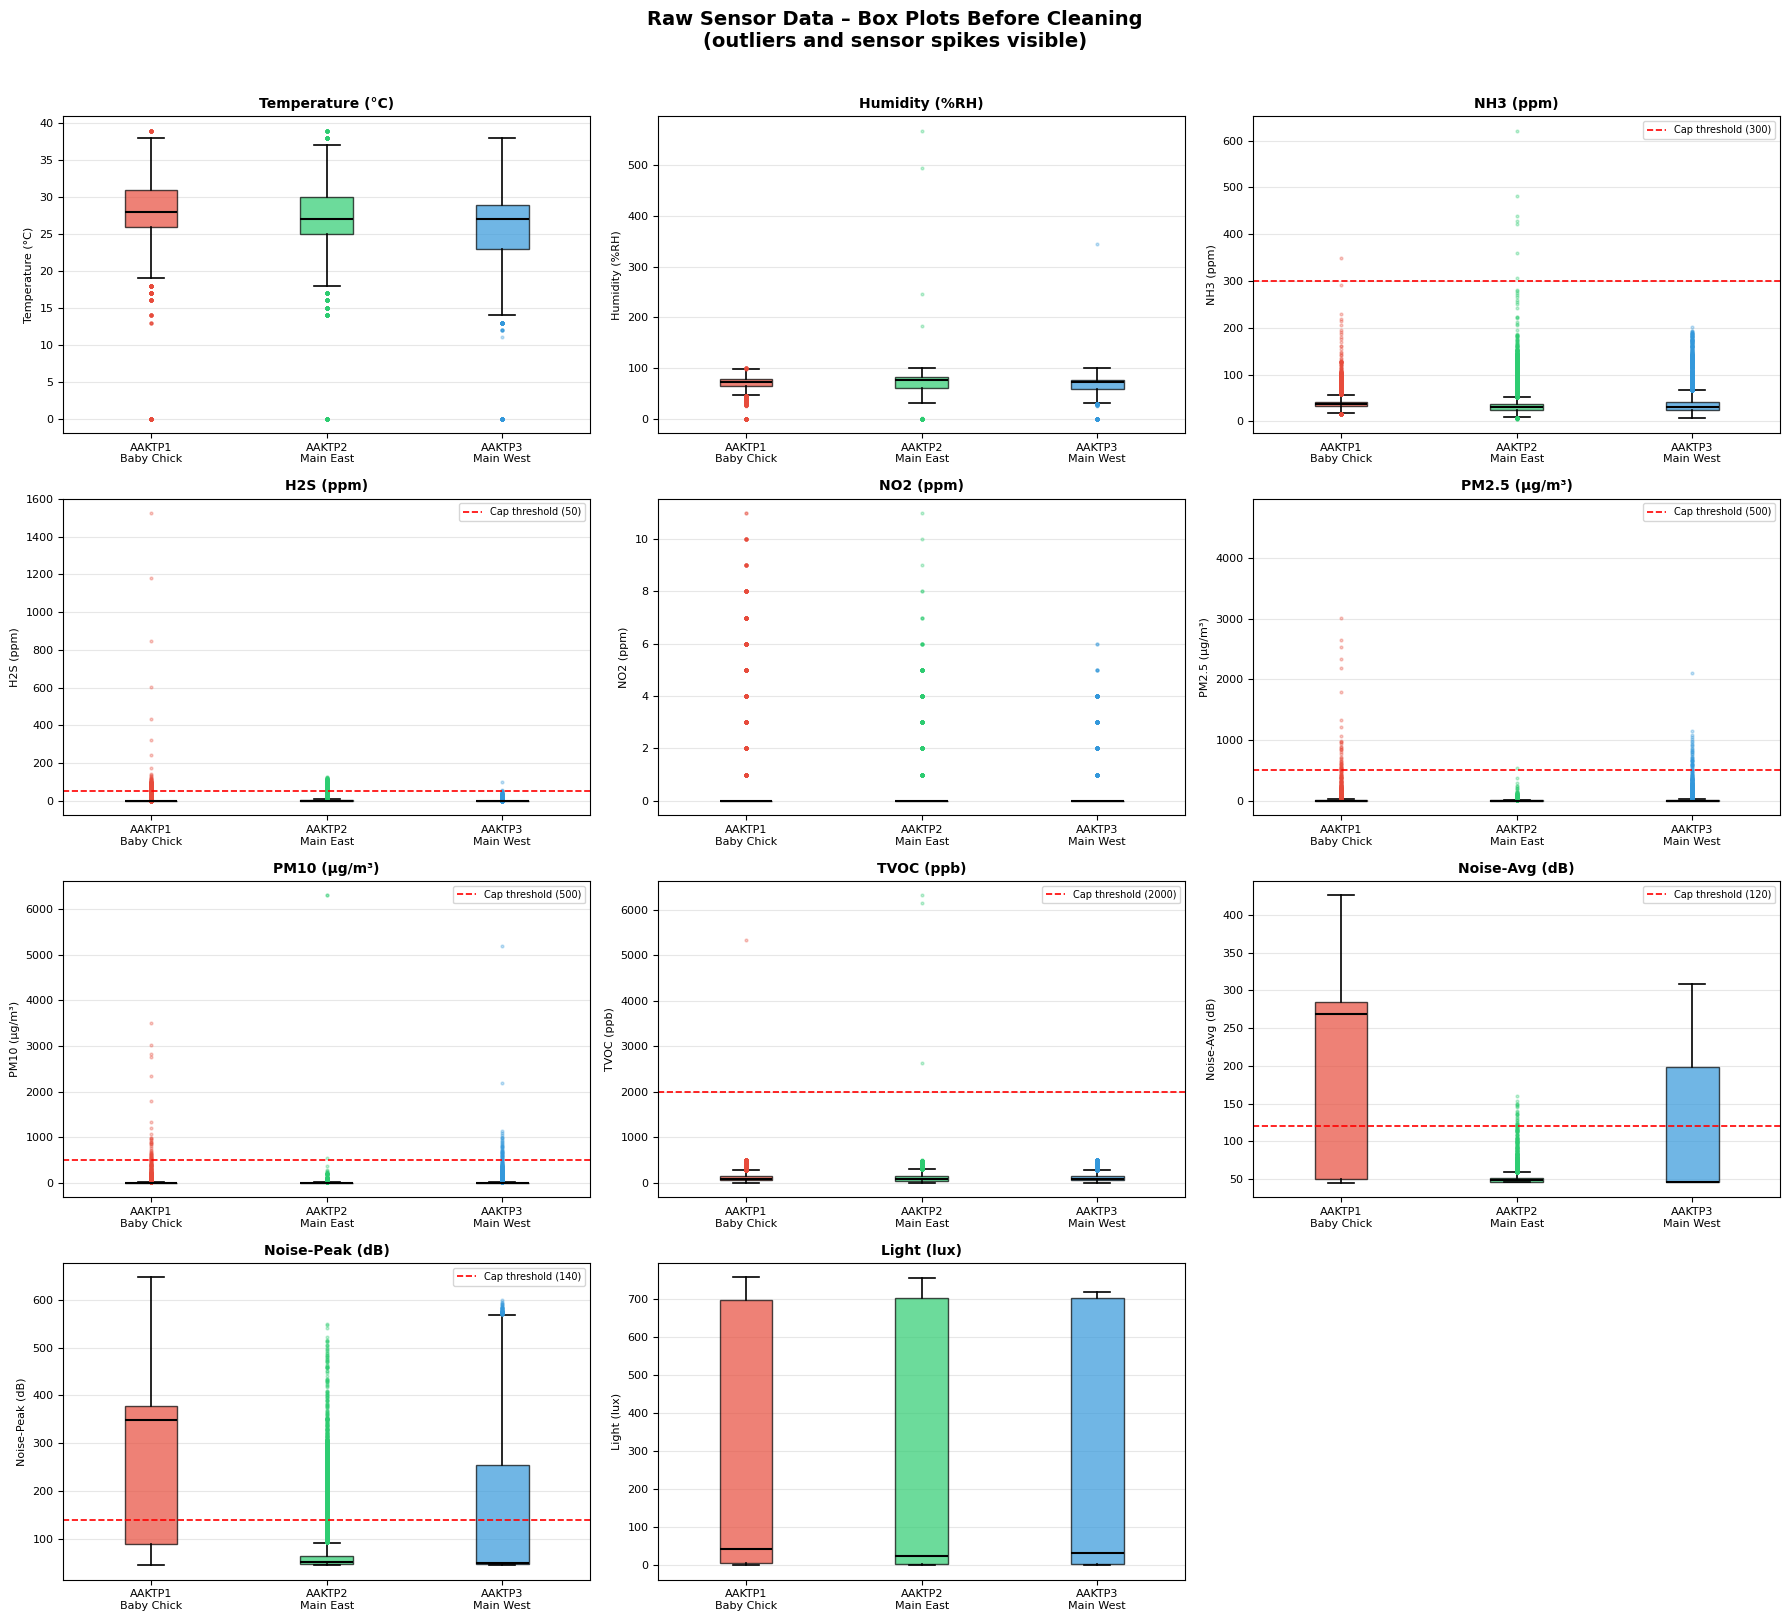


Pre-Cleaning Spike Summary (values exceeding cap thresholds):
  AAKTP1 | NH3          > 300: 1 rows (0.00%)
  AAKTP2 | NH3          > 300: 7 rows (0.01%)
  AAKTP1 | H2S          > 50: 157 rows (0.18%)
  AAKTP2 | H2S          > 50: 515 rows (0.64%)
  AAKTP3 | H2S          > 50: 3 rows (0.00%)
  AAKTP1 | PM2-5        > 500: 43 rows (0.05%)
  AAKTP2 | PM2-5        > 500: 1 rows (0.00%)
  AAKTP3 | PM2-5        > 500: 44 rows (0.05%)
  AAKTP1 | PM10         > 500: 43 rows (0.05%)
  AAKTP2 | PM10         > 500: 3 rows (0.00%)
  AAKTP3 | PM10         > 500: 44 rows (0.05%)
  AAKTP1 | TVOC         > 2000: 1 rows (0.00%)
  AAKTP2 | TVOC         > 2000: 3 rows (0.00%)
  AAKTP1 | Noise-Avg    > 120: 53,516 rows (62.24%)
  AAKTP2 | Noise-Avg    > 120: 25 rows (0.03%)
  AAKTP3 | Noise-Avg    > 120: 34,257 rows (39.32%)
  AAKTP1 | Noise-Peak   > 140: 57,607 rows (67.00%)
  AAKTP2 | Noise-Peak   > 140: 4,588 rows (5.67%)
  AAKTP3 | Noise-Peak   > 140: 35,715 rows (40.99%)

Pre-cleaning visualisation

In [ ]:
# Data visualization
# Step 2B Pre-Cleaning Outlier Visualisation
# Box plots of all numeric sensor parameters BEFORE any cleaning.
# This visualises the raw outliers and sensor spikes that will be
# addressed in Step 3, providing justification for the cleaning decisions.

print('PRE-CLEANING OUTLIER VISUALISATION')


import math

# Convert raw nodes to pandas for plotting
pd_raw1 = node1.toPandas()
pd_raw2 = node2.toPandas()
pd_raw3 = node3.toPandas()

# Add node labels
pd_raw1['Node'] = 'AAKTP1\nBaby Chick'
pd_raw2['Node'] = 'AAKTP2\nMain East'
pd_raw3['Node'] = 'AAKTP3\nMain West'

pd_raw_all = pd.concat([pd_raw1, pd_raw2, pd_raw3], ignore_index=True)

# Parameters to plot
params = [
    ('Temperature',  'Temperature (°C)',    None),
    ('Humidity',     'Humidity (%RH)',       None),
    ('NH3',          'NH3 (ppm)',            300),
    ('H2S',          'H2S (ppm)',            50),
    ('NO2',          'NO2 (ppm)',            None),
    ('PM2-5',        'PM2.5 (µg/m³)',        500),
    ('PM10',         'PM10 (µg/m³)',         500),
    ('TVOC',         'TVOC (ppb)',           2000),
    ('Noise-Avg',    'Noise-Avg (dB)',       120),
    ('Noise-Peak',   'Noise-Peak (dB)',      140),
    ('Light',        'Light (lux)',          None),
]

node_order  = ['AAKTP1\nBaby Chick', 'AAKTP2\nMain East', 'AAKTP3\nMain West']
node_colors = ['#E74C3C', '#2ECC71', '#3498DB']

n_cols = 3
n_rows = math.ceil(len(params) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
fig.suptitle(
    'Raw Sensor Data – Box Plots Before Cleaning\n(outliers and sensor spikes visible)',
    fontsize=14, fontweight='bold', y=1.01
)

for idx, (param, label, cap) in enumerate(params):
    ax = axes[idx // n_cols][idx % n_cols]

    # Build per-node arrays in consistent order
    data_groups = [
        pd_raw_all.loc[pd_raw_all['Node'] == n, param].dropna().astype(float).values
        for n in node_order
    ]

    bp = ax.boxplot(
        data_groups,
        patch_artist=True,
        notch=False,
        showfliers=True,
        flierprops=dict(marker='o', markersize=2, alpha=0.3, linestyle='none'),
        medianprops=dict(color='black', linewidth=1.5),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
    )

    # Colour each box
    for patch, colour in zip(bp['boxes'], node_colors):
        patch.set_facecolor(colour)
        patch.set_alpha(0.7)

    # Colour fliers to match their box
    for i, (flier, colour) in enumerate(zip(bp['fliers'], node_colors)):
        flier.set_markerfacecolor(colour)
        flier.set_markeredgecolor(colour)

    # Cap reference line
    if cap is not None:
        ax.axhline(
            y=cap, color='red', linestyle='--', linewidth=1.2,
            label=f'Cap threshold ({cap})'
        )
        ax.legend(fontsize=7, loc='upper right')

    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(node_order, fontsize=8)
    ax.set_ylabel(label, fontsize=8)
    ax.grid(True, axis='y', alpha=0.3)
    ax.tick_params(axis='y', labelsize=8)

# Hide any unused subplots
for idx in range(len(params), n_rows * n_cols):
    axes[idx // n_cols][idx % n_cols].set_visible(False)

plt.tight_layout()
plt.show()

#  Per-parameter spike summary printed below the chart
print('\nPre-Cleaning Spike Summary (values exceeding cap thresholds):')
caps_to_check = {
    'NH3':        300,
    'H2S':        50,
    'PM2-5':      500,
    'PM10':       500,
    'TVOC':       2000,
    'Noise-Avg':  120,
    'Noise-Peak': 140,
}
for param, cap in caps_to_check.items():
    for node_label, node_df in [
        ('AAKTP1', pd_raw1),
        ('AAKTP2', pd_raw2),
        ('AAKTP3', pd_raw3)
    ]:
        col_data = pd_raw_all.loc[pd_raw_all['Node'].str.contains(node_label), param].dropna()
        spikes = (col_data > cap).sum()
        if spikes > 0:
            pct = 100 * spikes / len(col_data)
            print(f"  {node_label} | {param:<12} > {cap}: {spikes:,} rows ({pct:.2f}%)")

print('\nPre-cleaning visualisation complete.')

In [ ]:
# Step 3 – Data Pre-processing & Cleaning
#
# Operations performed in order:
#  1. Parse timestamps with flexible format
#  2. Extract temporal features (Year, Month, Hour, etc.)
#  3. Remove null timestamps
#  4. Remove sensor outage rows – where Temperature=0 AND Humidity=0
#     simultaneously, indicating power/sensor failure (not real readings)
#  4b. Remove isolated Temperature <= 0 readings (residual sensor error)
#  5. Remove physically impossible Humidity values (>100%RH)
#  6. Handle sensor spike outliers using domain-knowledge upper bounds:
#       - For Noise-Avg and Noise-Peak, faulty values are set to NULL
#         so valid readings in the same row are preserved
#       - For H2S, NH3, PM2.5, PM10, and TVOC, rows above the cap are removed
#         because they represent physically impossible or operationally implausible spikes
#  7. Remove duplicate timestamps
#  8. Sort by timestamp
#
# Sensor spike upper bounds (domain-knowledge caps)
#
# H2S: cap at 50 ppm
#   (99th percentile across nodes is ~14–17 ppm; any reading above 50 ppm
#    would require immediate evacuation and is therefore treated as a sensor fault,
#    e.g. the 1,526 ppm spike observed in the raw data)
#
# PM2.5 / PM10: cap at 500 µg/m³
#   (WHO 24-hour PM2.5 guideline is 15 µg/m³; 500 µg/m³ represents an extreme
#    industrial-level event, so raw spikes in the 3,000–4,745 range are treated
#    as sensor malfunctions rather than real poultry-house conditions)
#
# TVOC: cap at 2,000 ppb
#   (the critical threshold used later in the analysis is 1,000 ppb;
#    isolated raw spikes above 2,000 ppb are treated as sensor glitches)
#
# Noise-Avg: cap at 120 dB
#   (120 dB is widely recognised as the threshold of pain; raw data shows
#    AAKTP1 and AAKTP3 contain a very large number of values above this level,
#    including implausible indoor readings up to 426 dB. These are treated as
#    calibration/sensor faults, so the noise value is set to NULL rather than
#    deleting the whole row and losing valid gas, temperature, and humidity data)
#
# Noise-Peak: cap at 140 dB
#   (140 dB(C) is the statutory UK peak noise exposure limit under the
#    Control of Noise at Work Regulations 2005 and EU Directive 2003/10/EC;
#    values above this are treated as faulty noise measurements and set to NULL)
#
# NH3: cap at 300 ppm
#   (NIOSH IDLH for ammonia = 300 ppm; values above this imply immediate danger
#    and are operationally implausible in routine farm conditions, so they are
#    treated as sensor spikes and removed)
#
# References: HSE (2020) EH40/2005; HSE (2005) Control of Noise at Work
# Regulations 2005; European Parliament (2003) Directive 2003/10/EC;
# NIOSH (1994) IDLH Documentation: Ammonia.

from pyspark.sql.functions import (
    col, lit, count, avg, stddev, min, max, sum, round,
    when, to_timestamp, year, month, dayofmonth, hour,
    dayofweek, date_format, desc
)
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print('\n' + '=' * 65)
print('STEP 3 – DATA PRE-PROCESSING & CLEANING (UPDATED)')
print('=' * 65)

NON_NOISE_CAPS = {
    'H2S': 50,
    'PM2-5': 500,
    'PM10': 500,
    'TVOC': 2000,
    'NH3': 300
}

def preprocess_node(df, node_name):
    print(f"\nPRE-PROCESSING: {node_name}")
    raw_count = df.count()
    print(f"  Raw records                  : {raw_count:,}")

    # 1. Parse timestamps
    df = df.withColumn('Timestamp', to_timestamp('Time', 'd/M/yyyy H:mm'))

    # 2. Extract temporal features
    df = (
        df
        .withColumn('Year', year('Timestamp'))
        .withColumn('Month', month('Timestamp'))
        .withColumn('Day', dayofmonth('Timestamp'))
        .withColumn('Hour', hour('Timestamp'))
        .withColumn('DayOfWeek', dayofweek('Timestamp'))
        .withColumn('Date', date_format('Timestamp', 'yyyy-MM-dd'))
        .withColumn('MonthYear', date_format('Timestamp', 'yyyy-MM'))
    )

    # 3. Remove null timestamps
    df = df.filter(col('Timestamp').isNotNull())
    after_ts = df.count()
    print(f"  After null timestamp         : {after_ts:,} (removed {raw_count - after_ts:,})")

    # 4. Remove outage rows
    df = df.filter(~((col('Temperature') == 0) & (col('Humidity') == 0)))
    after_outage = df.count()
    print(f"  After outage removal         : {after_outage:,} (removed {after_ts - after_outage:,})")

    # 4b. Remove residual non-physical temperatures
    df = df.filter(col('Temperature') > 0)
    after_temp = df.count()
    print(f"  After temp > 0 filter        : {after_temp:,} (removed {after_outage - after_temp:,})")

    # 5. Remove impossible humidity
    df = df.filter(col('Humidity') <= 100)
    after_humidity = df.count()
    print(f"  After humidity <= 100        : {after_humidity:,} (removed {after_temp - after_humidity:,})")

    # 6A. Noise sensor faults: preserve row, null only faulty noise values
    noise_avg_faults = df.filter(col('Noise-Avg') > 120).count()
    noise_peak_faults = df.filter(col('Noise-Peak') > 140).count()

    df = df.withColumn(
        'Noise-Avg',
        when(col('Noise-Avg') > 120, None).otherwise(col('Noise-Avg'))
    ).withColumn(
        'Noise-Peak',
        when(col('Noise-Peak') > 140, None).otherwise(col('Noise-Peak'))
    )

    print(f"  Noise-Avg >120 set to NULL   : {noise_avg_faults:,}")
    print(f"  Noise-Peak >140 set to NULL  : {noise_peak_faults:,}")

    # 6B. Remove true spike outlier rows for non-noise variables only
    for param, cap in NON_NOISE_CAPS.items():
        spike_count = df.filter(col(param) > cap).count()
        df = df.filter(col(param) <= cap)
        if spike_count > 0:
            print(f"  Spike cap {param:<12} >{cap}: removed {spike_count:,} rows")

    after_spikes = df.count()

    # 7. Remove duplicate timestamps
    df = df.dropDuplicates(['Timestamp'])
    after_dup = df.count()
    print(f"  After dedup                  : {after_dup:,} (removed {after_spikes - after_dup:,})")

    # 8. Sort by timestamp
    df = df.orderBy('Timestamp')
    final_count = df.count()
    print(f"  Final clean count            : {final_count:,}")

    return df

node1_clean = preprocess_node(node1, 'Node 1 (AAKTP1 – Baby Chick)')
node2_clean = preprocess_node(node2, 'Node 2 (AAKTP2 – Main Farm East)')
node3_clean = preprocess_node(node3, 'Node 3 (AAKTP3 – Main Farm West)')


STEP 3 – DATA PRE-PROCESSING & CLEANING (UPDATED)

PRE-PROCESSING: Node 1 (AAKTP1 – Baby Chick)
  Raw records                  : 85,984
  After null timestamp         : 85,984 (removed 0)
  After outage removal         : 83,687 (removed 2,297)
  After temp > 0 filter        : 83,687 (removed 0)
  After humidity <= 100        : 83,687 (removed 0)
  Noise-Avg >120 set to NULL   : 51,219
  Noise-Peak >140 set to NULL  : 55,310
  Spike cap H2S          >50: removed 157 rows
  Spike cap PM2-5        >500: removed 43 rows
  Spike cap NH3          >300: removed 1 rows
  After dedup                  : 83,055 (removed 431)
  Final clean count            : 83,055

PRE-PROCESSING: Node 2 (AAKTP2 – Main Farm East)
  Raw records                  : 80,987
  After null timestamp         : 80,987 (removed 0)
  After outage removal         : 66,854 (removed 14,133)
  After temp > 0 filter        : 66,849 (removed 5)
  After humidity <= 100        : 66,849 (removed 0)
  Noise-Avg >120 set to NULL   : 2


STEP 3C – POST-CLEANING OUTLIER VISUALISATION


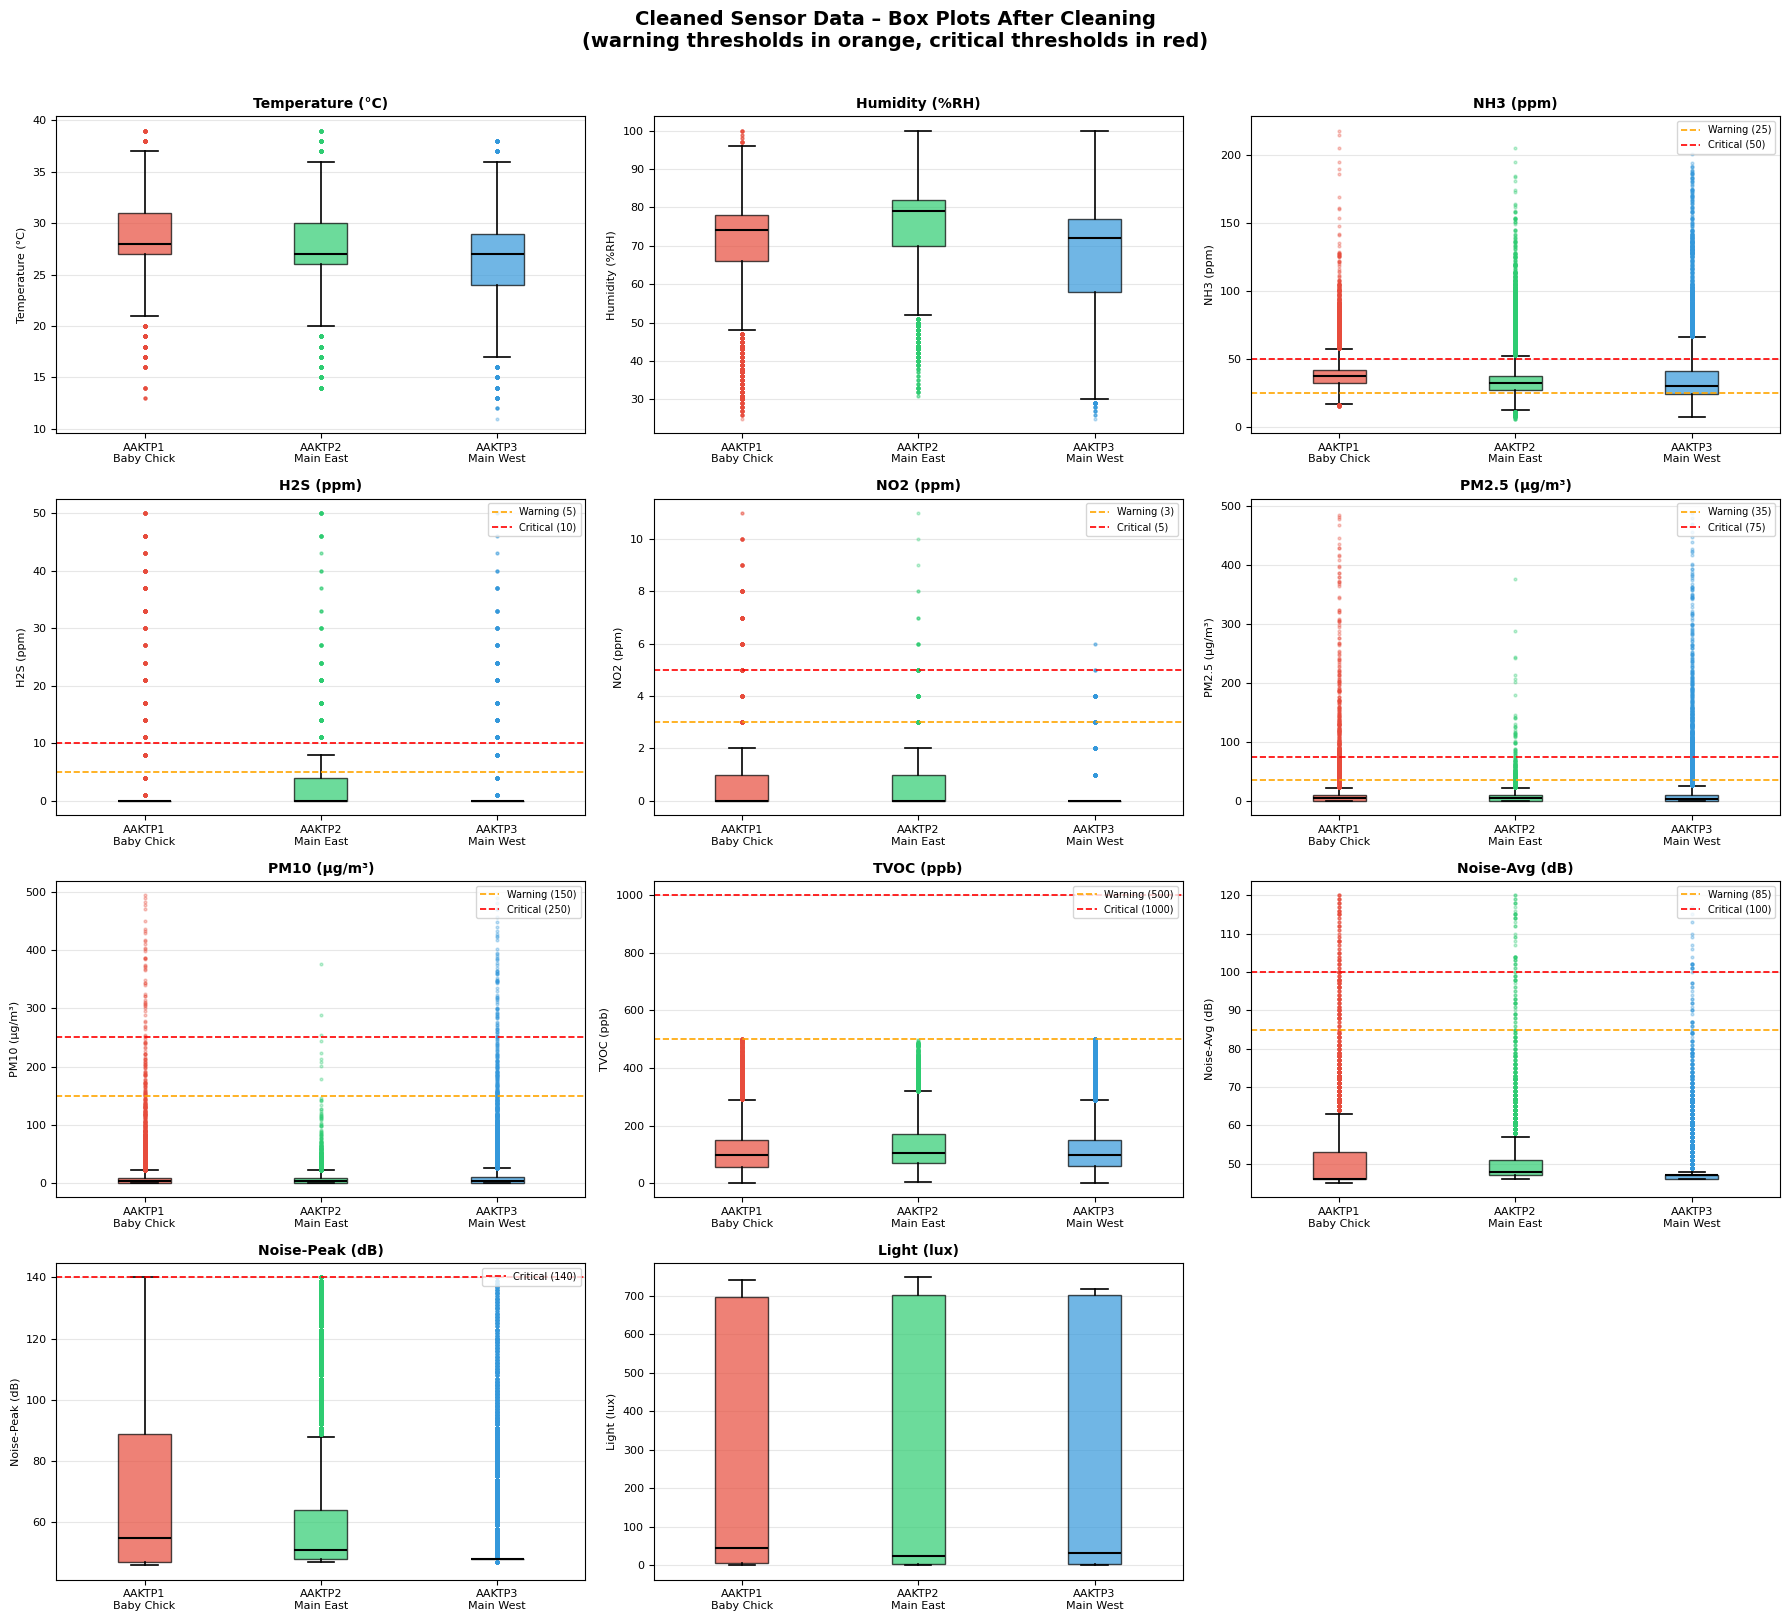


Post-Cleaning Value Range Summary:
  Temperature  mean=  27.59  max=  39.00
  Humidity     mean=  71.36  max= 100.00
  NH3          mean=  35.09  max= 218.00  >warning: 189,300 (80.5%)  >critical: 19,295 (8.2%)
  H2S          mean=   0.97  max=  50.00  >warning: 14,092 (6.0%)  >critical: 5,297 (2.3%)
  NO2          mean=   0.35  max=  11.00  >warning: 856 (0.4%)  >critical: 148 (0.1%)
  PM2-5        mean=   6.72  max= 489.00  >warning: 3,352 (1.4%)  >critical: 1,018 (0.4%)
  PM10         mean=   6.85  max= 494.00  >warning: 338 (0.1%)  >critical: 128 (0.1%)
  TVOC         mean= 118.55  max= 500.00  >warning: 0 (0.0%)  >critical: 0 (0.0%)
  Noise-Avg    mean=  49.06  max= 120.00  >warning: 355 (0.2%)  >critical: 147 (0.1%)
  Noise-Peak   mean=  59.09  max= 140.00  >critical: 0 (0.0%)
  Light        mean= 294.94  max= 748.00


In [ ]:
# =========================================================
# STEP 3C – POST-CLEANING OUTLIER VISUALISATION (UPDATED)
# =========================================================

print('\n' + '=' * 65)
print('STEP 3C – POST-CLEANING OUTLIER VISUALISATION')
print('=' * 65)

pd_clean1 = node1_clean.toPandas()
pd_clean2 = node2_clean.toPandas()
pd_clean3 = node3_clean.toPandas()

pd_clean1['NodeLabel'] = 'AAKTP1\nBaby Chick'
pd_clean2['NodeLabel'] = 'AAKTP2\nMain East'
pd_clean3['NodeLabel'] = 'AAKTP3\nMain West'

pd_clean_all = pd.concat([pd_clean1, pd_clean2, pd_clean3], ignore_index=True)

params_clean = [
    ('Temperature', 'Temperature (°C)', None, None),
    ('Humidity', 'Humidity (%RH)', None, None),
    ('NH3', 'NH3 (ppm)', 25, 50),
    ('H2S', 'H2S (ppm)', 5, 10),
    ('NO2', 'NO2 (ppm)', 3, 5),
    ('PM2-5', 'PM2.5 (µg/m³)', 35, 75),
    ('PM10', 'PM10 (µg/m³)', 150, 250),
    ('TVOC', 'TVOC (ppb)', 500, 1000),
    ('Noise-Avg', 'Noise-Avg (dB)', 85, 100),
    ('Noise-Peak', 'Noise-Peak (dB)', None, 140),
    ('Light', 'Light (lux)', None, None),
]

node_order = ['AAKTP1\nBaby Chick', 'AAKTP2\nMain East', 'AAKTP3\nMain West']
node_colors = ['#E74C3C', '#2ECC71', '#3498DB']

n_cols = 3
n_rows = math.ceil(len(params_clean) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
fig.suptitle(
    'Cleaned Sensor Data – Box Plots After Cleaning\n'
    '(warning thresholds in orange, critical thresholds in red)',
    fontsize=14, fontweight='bold', y=1.01
)

for idx, (param, label, warn, crit) in enumerate(params_clean):
    ax = axes[idx // n_cols][idx % n_cols]

    data_groups = [
        pd_clean_all.loc[pd_clean_all['NodeLabel'] == n, param].dropna().astype(float).values
        for n in node_order
    ]

    bp = ax.boxplot(
        data_groups,
        patch_artist=True,
        notch=False,
        showfliers=True,
        flierprops=dict(marker='o', markersize=2, alpha=0.3, linestyle='none'),
        medianprops=dict(color='black', linewidth=1.5),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
    )

    for patch, colour in zip(bp['boxes'], node_colors):
        patch.set_facecolor(colour)
        patch.set_alpha(0.7)

    for flier, colour in zip(bp['fliers'], node_colors):
        flier.set_markerfacecolor(colour)
        flier.set_markeredgecolor(colour)

    if warn is not None:
        ax.axhline(y=warn, color='orange', linestyle='--', linewidth=1.2, label=f'Warning ({warn})')
    if crit is not None:
        ax.axhline(y=crit, color='red', linestyle='--', linewidth=1.2, label=f'Critical ({crit})')

    if warn is not None or crit is not None:
        ax.legend(fontsize=7, loc='upper right')

    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(node_order, fontsize=8)
    ax.set_ylabel(label, fontsize=8)
    ax.grid(True, axis='y', alpha=0.3)
    ax.tick_params(axis='y', labelsize=8)

for idx in range(len(params_clean), n_rows * n_cols):
    axes[idx // n_cols][idx % n_cols].set_visible(False)

plt.tight_layout()
plt.show()

print('\nPost-Cleaning Value Range Summary:')
for param, label, warn, crit in params_clean:
    col_data = pd_clean_all[param].dropna().astype(float)
    if len(col_data) == 0:
        print(f"  {param:<12} all values NULL after cleaning")
        continue

    mean_val = col_data.mean()
    max_val = col_data.max()
    above_warn = (col_data > warn).sum() if warn is not None else 0
    above_crit = (col_data > crit).sum() if crit is not None else 0
    pct_warn = 100 * above_warn / len(col_data) if warn is not None else 0
    pct_crit = 100 * above_crit / len(col_data) if crit is not None else 0

    print(f"  {param:<12} mean={mean_val:>7.2f}  max={max_val:>7.2f}", end='')
    if warn is not None:
        print(f"  >warning: {above_warn:,} ({pct_warn:.1f}%)", end='')
    if crit is not None:
        print(f"  >critical: {above_crit:,} ({pct_crit:.1f}%)", end='')
    print()

## Step 4 – Data Quality Assessment

In [ ]:
# STEP 4 – DATA QUALITY ASSESSMENT (UPDATED)


def assess_data_quality(df, node_name):

    print(f"DATA QUALITY REPORT: {node_name}")


    total = df.count()
    print(f"Total clean records : {total:,}")

    time_stats = df.agg(
        min('Timestamp').alias('start'),
        max('Timestamp').alias('end')
    ).collect()[0]
    print(f"Time range          : {time_stats['start']}  →  {time_stats['end']}")

    print("\nNull Value Count (post-cleaning):")
    null_counts = df.select([
        count(when(col(c).isNull(), c)).alias(c)
        for c in [
            'Temperature','Humidity','Noise-Avg','Noise-Peak',
            'NH3','H2S','NO2','PM2-5','PM10','TVOC'
        ]
    ]).collect()[0]

    for k, v in null_counts.asDict().items():
        print(f"  {k}: {v}")

    print("\nNegative Value Count (post-cleaning):")
    for c in ['Temperature','Humidity','NH3','PM2-5','PM10','TVOC']:
        neg = df.filter(col(c) < 0).count()
        print(f"  {c}: {neg}")

    print("\nDescriptive Statistics:")
    df.select(
        'Temperature','Humidity','Noise-Avg','Noise-Peak',
        'NH3','H2S','NO2','PM2-5','PM10','TVOC'
    ).describe().show()

    return df

node1_clean = assess_data_quality(node1_clean, 'Node 1 (AAKTP1 – Baby Chick)')
node2_clean = assess_data_quality(node2_clean, 'Node 2 (AAKTP2 – Main Farm East)')
node3_clean = assess_data_quality(node3_clean, 'Node 3 (AAKTP3 – Main Farm West)')

DATA QUALITY REPORT: Node 1 (AAKTP1 – Baby Chick)
Total clean records : 83,055
Time range          : 2024-02-01 21:22:00  →  2025-07-04 14:18:00

Null Value Count (post-cleaning):
  Temperature: 0
  Humidity: 0
  Noise-Avg: 51064
  Noise-Peak: 55073
  NH3: 0
  H2S: 0
  NO2: 0
  PM2-5: 0
  PM10: 0
  TVOC: 0

Negative Value Count (post-cleaning):
  Temperature: 0
  Humidity: 0
  NH3: 0
  PM2-5: 0
  PM10: 0
  TVOC: 0

Descriptive Statistics:
+-------+------------------+------------------+------------------+-----------------+------------------+------------------+-------------------+------------------+------------------+-----------------+
|summary|       Temperature|          Humidity|         Noise-Avg|       Noise-Peak|               NH3|               H2S|                NO2|             PM2-5|              PM10|             TVOC|
+-------+------------------+------------------+------------------+-----------------+------------------+------------------+-------------------+-----------------

## Step 5 – Define Safety Thresholds

### Threshold Justification

The threshold values applied in this analysis were selected on the basis of
peer-reviewed literature and regulatory guidance to reflect both animal welfare
and human occupational safety considerations.

For ammonia (NH3), a three-tier classification is adopted. The warning threshold
of 25 ppm reflects the widely cited regulatory and scientific consensus that NH3
concentrations should be controlled below this level in poultry houses; prolonged
exposure above 25 ppm has been shown to cause respiratory irritation, impair
mucosal defences, reduce feed conversion efficiency, and increase susceptibility
to infectious disease in broilers (Carlile, 1984; Jones et al., 2000; Bist and
Chai, 2022). Importantly, Jones et al. (2000) note that the 25 ppm limit was
originally established on the basis of human safety rather than animal welfare,
suggesting that birds may be adversely affected even at concentrations at or
below this level. The critical threshold of 50 ppm is used as the action-required
level, at which severe and sustained welfare impacts including significant
respiratory tract damage and immune suppression are documented (Bist and Chai,
2022). The human danger threshold of 100 ppm corresponds to the UK Health and
Safety Executive Workplace Exposure Limit (WEL) for ammonia as defined in
EH40/2005, which sets the 8-hour time-weighted average at 25 ppm and the
short-term 15-minute exposure limit at 35 ppm, with concentrations above 100 ppm
constituting acute inhalation danger for workers (HSE, 2020).

For temperature, node-specific thresholds are applied because the thermal
requirements of newly hatched chicks differ fundamentally from those of grow-out
birds. For AAKTP1 (Baby Chick, Day 1–7), an ideal range of 29–33°C is used,
consistent with commercial brooding guidance recommending house temperatures of
30–33°C at chick arrival, reducing by approximately 2°C per week as feathering
develops (Aviagen, 2018; Cobb-Vantress, 2020). Day-old chicks cannot
thermoregulate independently, making precise temperature control critical for
survival and early organ development. For AAKTP2 and AAKTP3 (grow-out sections),
an ideal range of 18–24°C is applied, which is the standard thermal comfort zone
for broilers at market age, beyond which feed intake declines and heat stress
begins (Cobb-Vantress, 2020).

For particulate matter, the warning threshold of 35 µg/m³ for PM2.5 and 150
µg/m³ for PM10 are derived from the US Environmental Protection Agency National
Ambient Air Quality Standards (NAAQS), which set these as 24-hour reference
concentrations widely adopted as health-protective benchmarks in poultry
air-quality literature (US EPA, 2012; Bist and Chai, 2022). The critical
thresholds of 75 µg/m³ for PM2.5 and 250 µg/m³ for PM10 represent approximately
double the warning levels, at which point respiratory tract inflammation, alveolar
damage, and immune suppression are documented in both birds and human workers
(Zhang et al., 2023). Thresholds for hydrogen sulphide (warning 5 ppm, critical
10 ppm), nitrogen dioxide (warning 3 ppm, critical 5 ppm), average noise (warning
85 dB, critical 100 dB), and TVOC (warning 500 ppb, critical 1,000 ppb) are
consistent with standard occupational health and poultry environmental management
guidance (HSE, 2020).


In [ ]:
print('ENVIRONMENTAL SAFETY THRESHOLDS')


thresholds = {
    # ── Temperature: NODE-SPECIFIC
    # Baby chick (AAKTP1): newly hatched chicks need 29–33°C
    # Grow-out birds (AAKTP2/3): 18–24°C is optimal
    'Temperature_BabyChick': {
        'ideal_min': 29, 'ideal_max': 33,
        'critical_min': 24, 'critical_max': 37
    },
    'Temperature_MainFarm': {
        'ideal_min': 18, 'ideal_max': 24,
        'critical_min': 12, 'critical_max': 30
    },
    # ── Humidity
    'Humidity': {
        'ideal_min': 50, 'ideal_max': 70,
        'critical_min': 40, 'critical_max': 80
    },
    # ── NH3 – three-tier
    'NH3': {
        'warning_max': 25,    # welfare concern begins
        'critical_max': 50,   # serious welfare risk – action required
        'human_max': 100      # UK COSHH occupational exposure limit
    },
    # ── Particulate matter
    'PM2_5': {'warning_max': 35,  'critical_max': 75},
    'PM10':  {'warning_max': 150, 'critical_max': 250},
    # ── Gases
    'H2S':   {'warning_max': 5,   'critical_max': 10},
    'NO2':   {'warning_max': 3,   'critical_max': 5},
    # ── Noise / TVOC
    'Noise_Avg': {'warning_max': 85,  'critical_max': 100},
    'TVOC':      {'warning_max': 500, 'critical_max': 1000}
}

for param, limits in thresholds.items():
    print(f"\n{param}:")
    for key, value in limits.items():
        print(f"  {key}: {value}")

ENVIRONMENTAL SAFETY THRESHOLDS

Temperature_BabyChick:
  ideal_min: 29
  ideal_max: 33
  critical_min: 24
  critical_max: 37

Temperature_MainFarm:
  ideal_min: 18
  ideal_max: 24
  critical_min: 12
  critical_max: 30

Humidity:
  ideal_min: 50
  ideal_max: 70
  critical_min: 40
  critical_max: 80

NH3:
  warning_max: 25
  critical_max: 50
  human_max: 100

PM2_5:
  warning_max: 35
  critical_max: 75

PM10:
  warning_max: 150
  critical_max: 250

H2S:
  warning_max: 5
  critical_max: 10

NO2:
  warning_max: 3
  critical_max: 5

Noise_Avg:
  warning_max: 85
  critical_max: 100

TVOC:
  warning_max: 500
  critical_max: 1000


In [ ]:
from pyspark.sql.functions import when, col
all_nodes = node1_clean.unionByName(node2_clean).unionByName(node3_clean)
all_data = all_nodes.withColumnRenamed("Noise-Avg", "Noise_Avg") \
                   .withColumnRenamed("Noise-Peak", "Noise_Peak") \
                   .withColumnRenamed("PM2-5", "PM2_5")

# Temperature
all_data = all_data.withColumn(
    "Temperature_Status",
    when(
        (col("Section") == "Baby Chick (Day 1-7)") &
        ((col("Temperature") < thresholds['Temperature_BabyChick']['critical_min']) |
         (col("Temperature") > thresholds['Temperature_BabyChick']['critical_max'])),
        "Critical"
    ).when(
        (col("Section") == "Baby Chick (Day 1-7)") &
        ((col("Temperature") < thresholds['Temperature_BabyChick']['ideal_min']) |
         (col("Temperature") > thresholds['Temperature_BabyChick']['ideal_max'])),
        "Warning"
    ).when(
        (col("Section") != "Baby Chick (Day 1-7)") &
        ((col("Temperature") < thresholds['Temperature_MainFarm']['critical_min']) |
         (col("Temperature") > thresholds['Temperature_MainFarm']['critical_max'])),
        "Critical"
    ).when(
        (col("Section") != "Baby Chick (Day 1-7)") &
        ((col("Temperature") < thresholds['Temperature_MainFarm']['ideal_min']) |
         (col("Temperature") > thresholds['Temperature_MainFarm']['ideal_max'])),
        "Warning"
    ).otherwise("Optimal")
)

# NH3
all_data = all_data.withColumn(
    "NH3_Status",
    when(col("NH3") > thresholds['NH3']['human_max'], "Human Danger")
    .when(col("NH3") > thresholds['NH3']['critical_max'], "Critical")
    .when(col("NH3") > thresholds['NH3']['warning_max'], "Warning")
    .otherwise("Safe")
)

# Humidity
all_data = all_data.withColumn(
    "Humidity_Status",
    when(
        (col("Humidity") < thresholds['Humidity']['critical_min']) |
        (col("Humidity") > thresholds['Humidity']['critical_max']),
        "Critical"
    ).when(
        (col("Humidity") < thresholds['Humidity']['ideal_min']) |
        (col("Humidity") > thresholds['Humidity']['ideal_max']),
        "Warning"
    ).otherwise("Optimal")
)

# PM2.5
all_data = all_data.withColumn(
    "PM2_5_Status",
    when(col("PM2_5") > thresholds['PM2_5']['critical_max'], "Critical")
    .when(col("PM2_5") > thresholds['PM2_5']['warning_max'], "Warning")
    .otherwise("Safe")
)

# PM10
all_data = all_data.withColumn(
    "PM10_Status",
    when(col("PM10") > thresholds['PM10']['critical_max'], "Critical")
    .when(col("PM10") > thresholds['PM10']['warning_max'], "Warning")
    .otherwise("Safe")
)

# H2S
all_data = all_data.withColumn(
    "H2S_Status",
    when(col("H2S") > thresholds['H2S']['critical_max'], "Critical")
    .when(col("H2S") > thresholds['H2S']['warning_max'], "Warning")
    .otherwise("Safe")
)

# NO2
all_data = all_data.withColumn(
    "NO2_Status",
    when(col("NO2") > thresholds['NO2']['critical_max'], "Critical")
    .when(col("NO2") > thresholds['NO2']['warning_max'], "Warning")
    .otherwise("Safe")
)

# Noise
all_data = all_data.withColumn(
    "Noise_Status",
    when(col("Noise_Avg") > thresholds['Noise_Avg']['critical_max'], "Critical")
    .when(col("Noise_Avg") > thresholds['Noise_Avg']['warning_max'], "Warning")
    .otherwise("Safe")
)

# TVOC
all_data = all_data.withColumn(
    "TVOC_Status",
    when(col("TVOC") > thresholds['TVOC']['critical_max'], "Critical")
    .when(col("TVOC") > thresholds['TVOC']['warning_max'], "Warning")
    .otherwise("Safe")
)
all_data.select(
    "Section",
    "Temperature_Status",
    "NH3_Status",
    "Humidity_Status",
    "PM2_5_Status",
    "Noise_Status"
).show(50)

+--------------------+------------------+------------+---------------+------------+------------+
|             Section|Temperature_Status|  NH3_Status|Humidity_Status|PM2_5_Status|Noise_Status|
+--------------------+------------------+------------+---------------+------------+------------+
|Baby Chick (Day 1-7)|          Critical|Human Danger|        Warning|        Safe|        Safe|
|Baby Chick (Day 1-7)|          Critical|    Critical|        Optimal|    Critical|        Safe|
|Baby Chick (Day 1-7)|          Critical|    Critical|        Optimal|        Safe|        Safe|
|Baby Chick (Day 1-7)|          Critical|    Critical|        Optimal|        Safe|        Safe|
|Baby Chick (Day 1-7)|          Critical|    Critical|        Optimal|        Safe|        Safe|
|Baby Chick (Day 1-7)|          Critical|    Critical|        Optimal|        Safe|        Safe|
|Baby Chick (Day 1-7)|          Critical|    Critical|        Optimal|        Safe|        Safe|
|Baby Chick (Day 1-7)|        

## Step 6 – Descriptive Statistics & Aggregations
This step computes summary statistics for each node including mean, standard deviation, min and max values for all environmental parameters. All three cleaned node datasets are combined into a single DataFrame and grouped by node to enable direct comparison across the baby chick and main farm sections.

In [ ]:
# STEP 6 – DESCRIPTIVE STATISTICS & AGGREGATIONS (UPDATED)

print('DESCRIPTIVE STATISTICS BY NODE')


node1_clean.cache()
node2_clean.cache()
node3_clean.cache()

print('Integrity checks before union:')
print(f"  Node1 clean count: {node1_clean.count():,}")
print(f"  Node2 clean count: {node2_clean.count():,}")
print(f"  Node3 clean count: {node3_clean.count():,}")

all_nodes = node1_clean.unionByName(node2_clean).unionByName(node3_clean).cache()

assert all_nodes.filter(col('Temperature') <= 0).count() == 0, "Temperature cleaning failed"
assert all_nodes.filter(col('NH3') > 300).count() == 0, "NH3 cleaning failed"

print(f"  Combined all_nodes count: {all_nodes.count():,}")

stats_by_node = all_nodes.groupBy('Node', 'Section').agg(
    count('*').alias('Total_Records'),
    round(avg('Temperature'), 2).alias('Avg_Temp'),
    round(stddev('Temperature'), 2).alias('StdDev_Temp'),
    min('Temperature').alias('Min_Temp'),
    max('Temperature').alias('Max_Temp'),
    round(avg('Humidity'), 2).alias('Avg_Humidity'),
    round(avg('NH3'), 2).alias('Avg_NH3'),
    max('NH3').alias('Max_NH3'),
    round(avg(col('PM2-5')), 2).alias('Avg_PM2_5'),
    max(col('PM2-5')).alias('Max_PM2_5'),
    round(avg('H2S'), 2).alias('Avg_H2S'),
    round(avg('NO2'), 2).alias('Avg_NO2'),
    round(avg(col('Noise-Avg')), 2).alias('Avg_Noise'),
    round(avg('TVOC'), 2).alias('Avg_TVOC')
).orderBy('Node')

print('Summary Statistics by Node:')
stats_by_node.show(truncate=False)

print('\nCoverage note:')
coverage = all_nodes.groupBy('Node').agg(
    min('Timestamp').alias('Start_Time'),
    max('Timestamp').alias('End_Time'),
    count('*').alias('Rows')
).orderBy('Node')
coverage.show(truncate=False)

DESCRIPTIVE STATISTICS BY NODE
Integrity checks before union:
  Node1 clean count: 83,055
  Node2 clean count: 65,993
  Node3 clean count: 86,131
  Combined all_nodes count: 235,179
Summary Statistics by Node:
+------+--------------------+-------------+--------+-----------+--------+--------+------------+-------+-------+---------+---------+-------+-------+---------+--------+
|Node  |Section             |Total_Records|Avg_Temp|StdDev_Temp|Min_Temp|Max_Temp|Avg_Humidity|Avg_NH3|Max_NH3|Avg_PM2_5|Max_PM2_5|Avg_H2S|Avg_NO2|Avg_Noise|Avg_TVOC|
+------+--------------------+-------------+--------+-----------+--------+--------+------------+-------+-------+---------+---------+-------+-------+---------+--------+
|AAKTP1|Baby Chick (Day 1-7)|83055        |28.74   |3.55       |13      |39      |70.96       |39.02  |218    |6.86     |486      |1.11   |0.38   |50.28    |114.57  |
|AAKTP2|Main Farm East      |65993        |28.1    |3.74       |14      |39      |75.54       |33.17  |205    |5.53     |3

## Step 7 – Identify Anomalies & Risk Conditions
Each sensor reading is classified into risk categories based on the thresholds defined in Step 5. Temperature classification is node-specific — AAKTP1 (baby chick) uses the 29–33°C ideal range while AAKTP2 and AAKTP3 (main farm) use 18–24°C. NH3 is classified across four tiers: Safe (≤25 ppm), Warning (26–50 ppm), Critical (51–100 ppm), and Human Danger (>100 ppm). The percentage of time spent at each risk level is then calculated per node.

In [ ]:

print('RISK ANALYSIS: THRESHOLD VIOLATIONS')


tc_bc  = thresholds['Temperature_BabyChick']
tc_mf  = thresholds['Temperature_MainFarm']
hc     = thresholds['Humidity']
nh3c   = thresholds['NH3']
h2sc   = thresholds['H2S']
pm25c  = thresholds['PM2_5']
no2c   = thresholds['NO2']

all_nodes_risk = (
    all_nodes

    # ── Temperature risk (node-specific) ────────────────────────────
    .withColumn('Temp_Risk',
        when(col('Node') == 'AAKTP1',
            when(
                (col('Temperature') < tc_bc['critical_min']) |
                (col('Temperature') > tc_bc['critical_max']), 'Critical'
            ).when(
                (col('Temperature') < tc_bc['ideal_min']) |
                (col('Temperature') > tc_bc['ideal_max']), 'Warning'
            ).otherwise('Safe')
        ).otherwise(
            when(
                (col('Temperature') < tc_mf['critical_min']) |
                (col('Temperature') > tc_mf['critical_max']), 'Critical'
            ).when(
                (col('Temperature') < tc_mf['ideal_min']) |
                (col('Temperature') > tc_mf['ideal_max']), 'Warning'
            ).otherwise('Safe')
        )
    )

    # Humidity risk
    .withColumn('Humidity_Risk',
        when(
            (col('Humidity') < hc['critical_min']) |
            (col('Humidity') > hc['critical_max']), 'Critical'
        ).when(
            (col('Humidity') < hc['ideal_min']) |
            (col('Humidity') > hc['ideal_max']), 'Warning'
        ).otherwise('Safe')
    )

    # ── NH3 risk – three tiers
    .withColumn('NH3_Risk',
        when(col('NH3') > nh3c['human_max'],   'Human_Danger')
        .when(col('NH3') > nh3c['critical_max'], 'Critical')
        .when(col('NH3') > nh3c['warning_max'],  'Warning')
        .otherwise('Safe')
    )

    # ── H2S risk
    .withColumn('H2S_Risk',
        when(col('H2S') > h2sc['critical_max'], 'Critical')
        .when(col('H2S') > h2sc['warning_max'],  'Warning')
        .otherwise('Safe')
    )

    # ── PM2.5 risk
    .withColumn('PM2_5_Risk',
        when(col('PM2-5') > pm25c['critical_max'], 'Critical')
        .when(col('PM2-5') > pm25c['warning_max'],  'Warning')
        .otherwise('Safe')
    )

    # ── NO2 risk
    .withColumn('NO2_Risk',
        when(col('NO2') > no2c['critical_max'], 'Critical')
        .when(col('NO2') > no2c['warning_max'],  'Warning')
        .otherwise('Safe')
    )
)

# ── Risk summary by node
risk_summary = all_nodes_risk.groupBy('Node', 'Section').agg(
    count('*').alias('Total_Readings'),
    sum(when(col('Temp_Risk')  == 'Critical', 1).otherwise(0)).alias('Temp_Critical'),
    sum(when(col('Temp_Risk')  == 'Warning',  1).otherwise(0)).alias('Temp_Warning'),
    sum(when(col('NH3_Risk')   == 'Human_Danger', 1).otherwise(0)).alias('NH3_HumanDanger'),
    sum(when(col('NH3_Risk')    == 'Critical', 1).otherwise(0)).alias('NH3_Critical'),
    sum(when(col('NH3_Risk')    == 'Warning',  1).otherwise(0)).alias('NH3_Warning'),
    sum(when(col('PM2_5_Risk')  == 'Critical', 1).otherwise(0)).alias('PM25_Critical'),
    sum(when(col('PM2_5_Risk')  == 'Warning',  1).otherwise(0)).alias('PM25_Warning'),
    sum(when(col('Humidity_Risk') == 'Critical', 1).otherwise(0)).alias('Humidity_Critical'),
    sum(when(col('Humidity_Risk') == 'Warning',  1).otherwise(0)).alias('Humidity_Warning'),
    sum(when(col('H2S_Risk')    == 'Critical', 1).otherwise(0)).alias('H2S_Critical'),
    sum(when(col('H2S_Risk')    == 'Warning',  1).otherwise(0)).alias('H2S_Warning'),
    sum(when(col('NO2_Risk')    == 'Critical', 1).otherwise(0)).alias('NO2_Critical'),
    sum(when(col('NO2_Risk')     == 'Warning',  1).otherwise(0)).alias('NO2_Warning')
)

print('Risk Violations by Node:')
risk_summary.show(truncate=False)

#  Percentage of time at each NH3 tier
risk_pct = (
    risk_summary
    .withColumn('NH3_HumanDanger_Pct', round(col('NH3_HumanDanger') / col('Total_Readings') * 100, 2))
    .withColumn('NH3_Critical_Pct',    round(col('NH3_Critical')    / col('Total_Readings') * 100, 2))
    .withColumn('NH3_Warning_Pct',     round(col('NH3_Warning')     / col('Total_Readings') * 100, 2))
    .withColumn('Temp_Critical_Pct',   round(col('Temp_Critical')   / col('Total_Readings') * 100, 2))
    .withColumn('PM25_Critical_Pct',   round(col('PM25_Critical')   / col('Total_Readings') * 100, 2))
)

print('\nPercentage of Time at Each Risk Level:')
risk_pct.select(
    'Node', 'NH3_Warning_Pct', 'NH3_Critical_Pct',
    'NH3_HumanDanger_Pct', 'Temp_Critical_Pct', 'PM25_Critical_Pct'
).show()

RISK ANALYSIS: THRESHOLD VIOLATIONS
Risk Violations by Node:
+------+--------------------+--------------+-------------+------------+---------------+------------+-----------+-------------+------------+-----------------+----------------+------------+-----------+------------+-----------+
|Node  |Section             |Total_Readings|Temp_Critical|Temp_Warning|NH3_HumanDanger|NH3_Critical|NH3_Warning|PM25_Critical|PM25_Warning|Humidity_Critical|Humidity_Warning|H2S_Critical|H2S_Warning|NO2_Critical|NO2_Warning|
+------+--------------------+--------------+-------------+------------+---------------+------------+-----------+-------------+------------+-----------------+----------------+------------+-----------+------------+-----------+
|AAKTP1|Baby Chick (Day 1-7)|83055         |3888         |50226       |86             |11571       |66694      |320          |1035        |9975             |44362           |2629        |3376       |132         |414        |
|AAKTP2|Main Farm East      |65993     

## Step 8 – Temporal Analysis (Hourly, Daily, Monthly)
This step examines how environmental conditions change over time across three time scales. Monthly trends reveal seasonal patterns and longer-term deterioration. Hourly patterns expose circadian rhythms — particularly when NH3 and temperature co-peak during the day. Daily aggregations identify the worst individual days in terms of NH3 violations across all three nodes.

In [ ]:

# STEP 8 – TEMPORAL ANALYSIS (UPDATED)


print('TEMPORAL ANALYSIS')


print('\n1. MONTHLY TRENDS')


monthly_trends = all_nodes.groupBy('Node', 'MonthYear').agg(
    count('*').alias('Readings'),
    round(avg('Temperature'), 2).alias('Avg_Temp'),
    round(avg('Humidity'), 2).alias('Avg_Humidity'),
    round(avg('NH3'), 2).alias('Avg_NH3'),
    round(avg(col('PM2-5')), 2).alias('Avg_PM2_5'),
    max('NH3').alias('Max_NH3')
).orderBy('MonthYear', 'Node')

monthly_trends.show(50, truncate=False)

print('\n2. HOURLY PATTERNS (Circadian Rhythms)')


hourly_patterns = all_nodes.groupBy('Node', 'Hour').agg(
    round(avg('Temperature'), 2).alias('Avg_Temp'),
    round(avg('Humidity'), 2).alias('Avg_Humidity'),
    round(avg('Light'), 2).alias('Avg_Light'),
    round(avg(col('Noise-Avg')), 2).alias('Avg_Noise'),
    round(avg('NH3'), 2).alias('Avg_NH3')
).orderBy('Node', 'Hour')

hourly_patterns.show(72, truncate=False)

print('\n3. DAILY TRENDS (last 10 days)')


daily_trends = all_nodes.groupBy('Node', 'Date').agg(
    round(avg('Temperature'), 2).alias('Avg_Temp'),
    round(avg('Humidity'), 2).alias('Avg_Humidity'),
    round(avg('NH3'), 2).alias('Avg_NH3'),
    max('NH3').alias('Max_NH3'),
    sum(when(col('NH3') > 50, 1).otherwise(0)).alias('NH3_Violations')
).orderBy('Date', 'Node')

daily_trends.orderBy(desc('Date')).show(10, truncate=False)

print('\n4. WORST DAYS (highest NH3 peaks)')


worst_days = daily_trends.filter(col('Max_NH3') > 50).orderBy(desc('Max_NH3'))
worst_days.show(20, truncate=False)

TEMPORAL ANALYSIS

1. MONTHLY TRENDS
+------+---------+--------+--------+------------+-------+---------+-------+
|Node  |MonthYear|Readings|Avg_Temp|Avg_Humidity|Avg_NH3|Avg_PM2_5|Max_NH3|
+------+---------+--------+--------+------------+-------+---------+-------+
|AAKTP1|2024-02  |1390    |18.51   |60.17       |64.55  |18.13    |218    |
|AAKTP2|2024-02  |1398    |15.3    |63.71       |43.33  |5.91     |105    |
|AAKTP3|2024-02  |6264    |18.97   |53.72       |31.2   |14.06    |47     |
|AAKTP1|2024-03  |55      |30.44   |61.56       |53.42  |15.64    |74     |
|AAKTP2|2024-03  |11      |29.91   |66.64       |79.55  |11.18    |81     |
|AAKTP3|2024-03  |7609    |16.82   |54.49       |25.5   |12.94    |42     |
|AAKTP1|2024-04  |7683    |30.67   |72.61       |48.84  |12.07    |89     |
|AAKTP2|2024-04  |7442    |30.35   |72.18       |60.19  |9.82     |205    |
|AAKTP3|2024-04  |1879    |17.63   |54.47       |24.95  |4.47     |47     |
|AAKTP1|2024-05  |7906    |30.46   |71.37       |47

## Step 9 – Cross-Node Comparison: Baby Chick vs Main Farm
This step directly compares all environmental parameters across the three monitoring stations side by side. Key differences in temperature, NH3, PM2.5, H2S, NO2, noise, and TVOC are highlighted to understand how conditions differ between the baby chick section and the two main farm zones.

In [ ]:
print('\n' + '=' * 65)
print('NODE COMPARISON: Baby Chick Section vs Main Farm')
print('=' * 65 + '\n')

comparison = all_nodes.groupBy('Node', 'Section').agg(
    round(avg('Temperature'), 2).alias('Avg_Temp'),
    round(stddev('Temperature'), 2).alias('Temp_StdDev'),
    round(avg('Humidity'), 2).alias('Avg_Humidity'),
    round(avg('NH3'), 2).alias('Avg_NH3'),
    max('NH3').alias('Max_NH3'),
    round(avg('H2S'), 2).alias('Avg_H2S'),
    round(avg('NO2'), 2).alias('Avg_NO2'),
    round(avg(col('PM2-5')), 2).alias('Avg_PM2_5'),
    max(col('PM2-5')).alias('Max_PM2_5'),
    round(avg('PM10'), 2).alias('Avg_PM10'),
    round(avg('Light'), 2).alias('Avg_Light'),
    round(avg(col('Noise-Avg')), 2).alias('Avg_Noise'),
    round(avg('TVOC'), 2).alias('Avg_TVOC')
).orderBy('Node')

print('Environmental Comparison Across All Nodes:')
comparison.show(truncate=False)

# Print key differences clearly
n1s = comparison.filter(col('Node') == 'AAKTP1').collect()[0]
n2s = comparison.filter(col('Node') == 'AAKTP2').collect()[0]
n3s = comparison.filter(col('Node') == 'AAKTP3').collect()[0]

print('\n' + '=' * 50)
print('KEY DIFFERENCES (post-cleaning):')
print('=' * 50)
print(f"\nTemperature (°C):")
print(f"  Baby Chick AAKTP1 : {n1s['Avg_Temp']}  [ideal 29-33°C for chicks]")
print(f"  Main East  AAKTP2 : {n2s['Avg_Temp']}  [ideal 18-24°C for grow-out]")
print(f"  Main West  AAKTP3 : {n3s['Avg_Temp']}  [ideal 18-24°C for grow-out]")

print(f"\nAmmonia NH3 (ppm) — warning 25 | critical 50 | human 100:")
print(f"  Baby Chick AAKTP1 : avg {n1s['Avg_NH3']}  max {n1s['Max_NH3']}")
print(f"  Main East  AAKTP2 : avg {n2s['Avg_NH3']}  max {n2s['Max_NH3']}")
print(f"  Main West  AAKTP3 : avg {n3s['Avg_NH3']}  max {n3s['Max_NH3']}")

print(f"\nPM2.5 (µg/m³) — warning 35 | critical 75:")
print(f"  Baby Chick AAKTP1 : avg {n1s['Avg_PM2_5']}")
print(f"  Main East  AAKTP2 : avg {n2s['Avg_PM2_5']}")
print(f"  Main West  AAKTP3 : avg {n3s['Avg_PM2_5']}")


NODE COMPARISON: Baby Chick Section vs Main Farm

Environmental Comparison Across All Nodes:
+------+--------------------+--------+-----------+------------+-------+-------+-------+-------+---------+---------+--------+---------+---------+--------+
|Node  |Section             |Avg_Temp|Temp_StdDev|Avg_Humidity|Avg_NH3|Max_NH3|Avg_H2S|Avg_NO2|Avg_PM2_5|Max_PM2_5|Avg_PM10|Avg_Light|Avg_Noise|Avg_TVOC|
+------+--------------------+--------+-----------+------------+-------+-------+-------+-------+---------+---------+--------+---------+---------+--------+
|AAKTP1|Baby Chick (Day 1-7)|28.74   |3.55       |70.96       |39.02  |218    |1.11   |0.38   |6.86     |486      |6.99    |295.73   |50.28    |114.57  |
|AAKTP2|Main Farm East      |28.1    |3.74       |75.54       |33.17  |205    |1.78   |0.4    |5.53     |376      |5.64    |322.05   |49.95    |125.89  |
|AAKTP3|Main Farm West      |26.09   |5.2        |68.55       |32.78  |201    |0.2    |0.29   |7.5      |489      |7.63    |273.41   |47

## Step 10 – Correlation Analysis
A Pearson correlation matrix is computed across all eight numeric environmental parameters using PySpark MLlib. This reveals which parameters move together — for example whether rising temperature drives higher NH3, or whether PM2.5 and PM10 share a common source. Strong correlations help prioritise which variables to target in farm management interventions.

In [ ]:
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler

print('\n' + '=' * 65)
print('CORRELATION ANALYSIS')
print('=' * 65 + '\n')

feature_cols = ['Temperature', 'Humidity', 'NH3', 'H2S', 'NO2', 'PM2-5', 'PM10', 'TVOC']

assembler  = VectorAssembler(inputCols=feature_cols, outputCol='features')
vector_df  = assembler.transform(all_nodes.select(feature_cols)).select('features')
corr_array = Correlation.corr(vector_df, 'features').head()[0].toArray()

corr_df = pd.DataFrame(corr_array, columns=feature_cols, index=feature_cols)
print('Correlation Matrix:')
print('=' * 65)
print(corr_df.round(3).to_string())

print('\n' + '=' * 50)
print('KEY CORRELATION INSIGHTS:')
print('=' * 50)
print(f"Temperature ↔ Humidity : {corr_df.loc['Temperature','Humidity']:.3f}")
print(f"Temperature ↔ NH3      : {corr_df.loc['Temperature','NH3']:.3f}  (warmer air = higher ammonia)")
print(f"NH3         ↔ NO2      : {corr_df.loc['NH3','NO2']:.3f}  (co-produced by organic decomposition)")
print(f"NH3         ↔ PM2-5    : {corr_df.loc['NH3','PM2-5']:.3f}")
print(f"PM2-5       ↔ PM10     : {corr_df.loc['PM2-5','PM10']:.3f}  (same dust source)")
print(f"Temperature ↔ TVOC     : {corr_df.loc['Temperature','TVOC']:.3f}  (heat drives VOC evaporation)")


CORRELATION ANALYSIS

Correlation Matrix:
             Temperature  Humidity    NH3    H2S    NO2  PM2-5   PM10   TVOC
Temperature        1.000    -0.182  0.243  0.113  0.112 -0.083 -0.078  0.320
Humidity          -0.182     1.000  0.083  0.105 -0.026  0.007  0.003 -0.258
NH3                0.243     0.083  1.000  0.136  0.660  0.075  0.086  0.005
H2S                0.113     0.105  0.136  1.000  0.115  0.030  0.033  0.080
NO2                0.112    -0.026  0.660  0.115  1.000  0.209  0.220  0.016
PM2-5             -0.083     0.007  0.075  0.030  0.209  1.000  0.997  0.108
PM10              -0.078     0.003  0.086  0.033  0.220  0.997  1.000  0.107
TVOC               0.320    -0.258  0.005  0.080  0.016  0.108  0.107  1.000

KEY CORRELATION INSIGHTS:
Temperature ↔ Humidity : -0.182
Temperature ↔ NH3      : 0.243  (warmer air = higher ammonia)
NH3         ↔ NO2      : 0.660  (co-produced by organic decomposition)
NH3         ↔ PM2-5    : 0.075
PM2-5       ↔ PM10     : 0.997  (same dus

## Step 11 – Advanced PySpark SQL Queries
Four SQL queries are run against the risk-classified dataset using Spark SQL:
- **Query 1** identifies the days with the highest number of critical environmental events
- **Query 2** calculates hourly NH3 and humidity compliance rates to pinpoint the most dangerous times of day
- **Query 3** ranks months by NH3 violation rate to identify seasonal peak risk periods
- **Query 4** computes 7-day moving averages for temperature and NH3 to smooth short-term fluctuations and reveal longer-term trends

In [ ]:

print('ADVANCED SQL QUERIES USING SPARK SQL')


all_nodes_risk.createOrReplaceTempView('environmental_data')

# ── Query 1: Critical environmental events ───────────────────────────────
print('QUERY 1: Critical Environmental Events (NH3>50 OR Temp out-of-range OR PM2.5>75)')
print('-' * 60)
query1 = """
SELECT
    Node, Section, Date,
    COUNT(*)   AS Critical_Events,
    MAX(NH3)      AS Max_Ammonia,
    MAX(Temperature)  AS Max_Temp,
    MAX(`PM2-5`)    AS Max_PM25
FROM environmental_data
WHERE NH3 > 50
   OR Temperature > 30
   OR `PM2-5` > 75
GROUP BY Node, Section, Date
ORDER BY Critical_Events DESC
LIMIT 20
"""
spark.sql(query1).show(truncate=False)

# ── Query 2: Hourly compliance rates ─────────────────────────────────────
print('\nQUERY 2: Hourly Compliance Rates')
print('-' * 60)
query2 = f"""
SELECT
    Node, Hour,
    COUNT(*) AS Total_Readings,
    ROUND(
        SUM(CASE WHEN NH3 <= 25  THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2
    ) AS NH3_Safe_Pct,
    ROUND(
        SUM(CASE WHEN NH3 BETWEEN 26 AND 50 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2
    ) AS NH3_Warning_Pct,
    ROUND(
        SUM(CASE WHEN NH3 > 50   THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2
    ) AS NH3_Critical_Pct,
    ROUND(
        SUM(CASE WHEN Humidity BETWEEN 50 AND 70 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2
    ) AS Humidity_Compliance_Pct,
    ROUND(AVG(NH3), 2) AS Avg_NH3
FROM environmental_data
GROUP BY Node, Hour
ORDER BY Node, Hour
"""
spark.sql(query2).show(24)

# ── Query 3: Peak risk periods by month ──────────────────────────────────
print('\nQUERY 3: Peak Risk Periods by Month')
print('-' * 60)
query3 = """
SELECT
    Node, MonthYear,
    COUNT(*) AS Total_Readings,
    SUM(CASE WHEN NH3 > 50  THEN 1 ELSE 0 END) AS NH3_Critical_Count,
    ROUND(
        SUM(CASE WHEN NH3 > 50 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2
    ) AS NH3_Critical_Pct,
    ROUND(AVG(NH3), 2) AS Avg_NH3,
    MAX(NH3)            AS Max_NH3
FROM environmental_data
GROUP BY Node, MonthYear
HAVING SUM(CASE WHEN NH3 > 50 THEN 1 ELSE 0 END) > 0
ORDER BY NH3_Critical_Pct DESC
"""
spark.sql(query3).show(20)

# ── Query 4: 7-day moving averages ───────────────────────────────────────
print('\nQUERY 4: 7-Day Moving Averages (Temperature & NH3)')
print('-' * 60)
query4 = """
SELECT
    Node, Date,
    ROUND(AVG(Temperature), 2)  AS Daily_Avg_Temp,
    ROUND(AVG(NH3), 2)    AS Daily_Avg_NH3,
    ROUND(AVG(AVG(Temperature)) OVER (
        PARTITION BY Node ORDER BY Date
        ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
    ), 2) AS Temp_7Day_MA,
    ROUND(AVG(AVG(NH3)) OVER (
        PARTITION BY Node ORDER BY Date
        ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
    ), 2) AS NH3_7Day_MA
FROM environmental_data
GROUP BY Node, Date
ORDER BY Node, Date DESC
"""
spark.sql(query4).show(30)

ADVANCED SQL QUERIES USING SPARK SQL
QUERY 1: Critical Environmental Events (NH3>50 OR Temp out-of-range OR PM2.5>75)
------------------------------------------------------------
+------+--------------------+----------+---------------+-----------+--------+--------+
|Node  |Section             |Date      |Critical_Events|Max_Ammonia|Max_Temp|Max_PM25|
+------+--------------------+----------+---------------+-----------+--------+--------+
|AAKTP1|Baby Chick (Day 1-7)|2024-02-03|288            |81         |21      |98      |
|AAKTP2|Main Farm East      |2024-04-05|288            |102        |37      |18      |
|AAKTP3|Main Farm West      |2024-06-04|288            |85         |35      |159     |
|AAKTP2|Main Farm East      |2024-04-04|287            |119        |37      |49      |
|AAKTP1|Baby Chick (Day 1-7)|2024-04-18|286            |74         |38      |70      |
|AAKTP1|Baby Chick (Day 1-7)|2024-05-13|286            |104        |38      |482     |
|AAKTP2|Main Farm East      |2024-04-1

Extra Visuals for Step 6,7,8

STEP 6 – DESCRIPTIVE STATISTICS GRAPHS


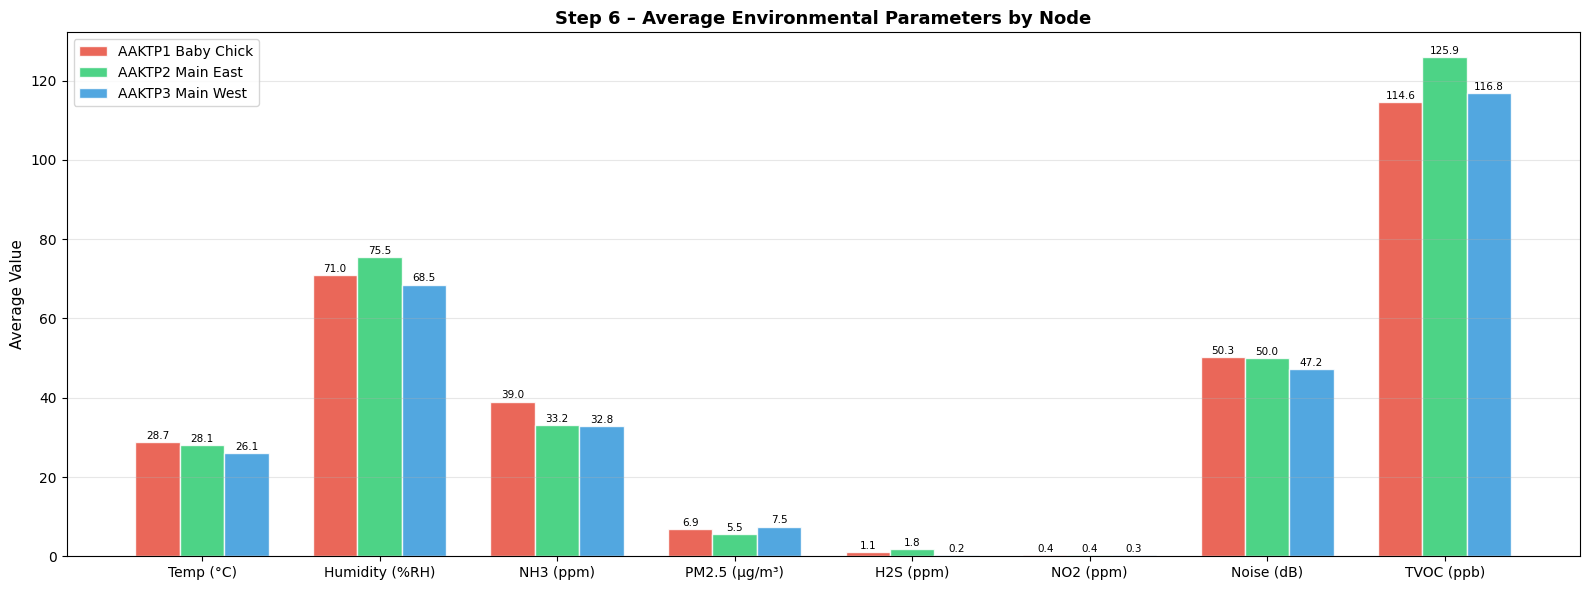

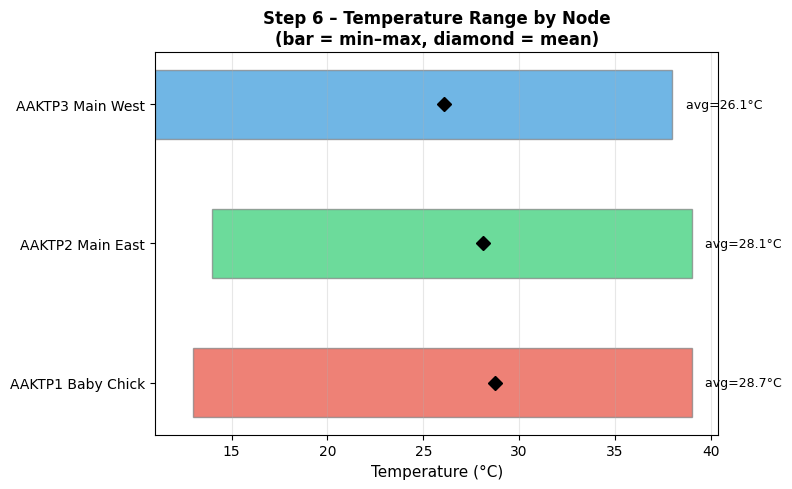

STEP 7 – ANOMALY & RISK CONDITION GRAPHS


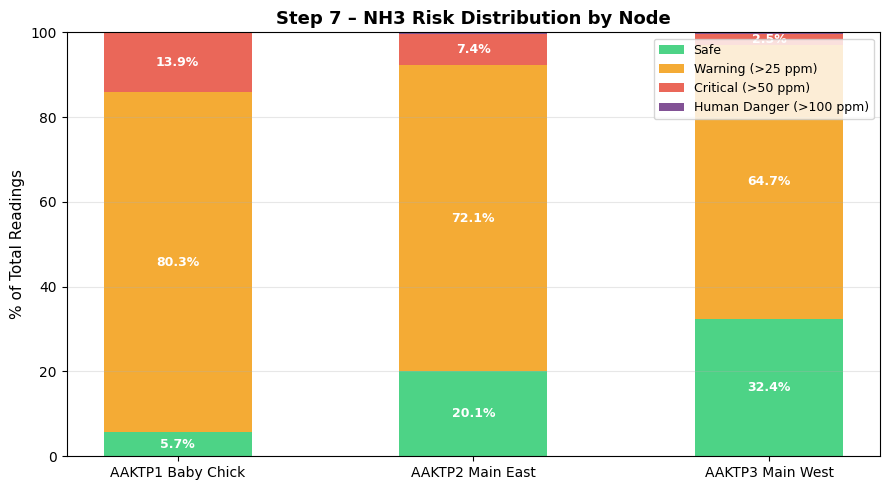

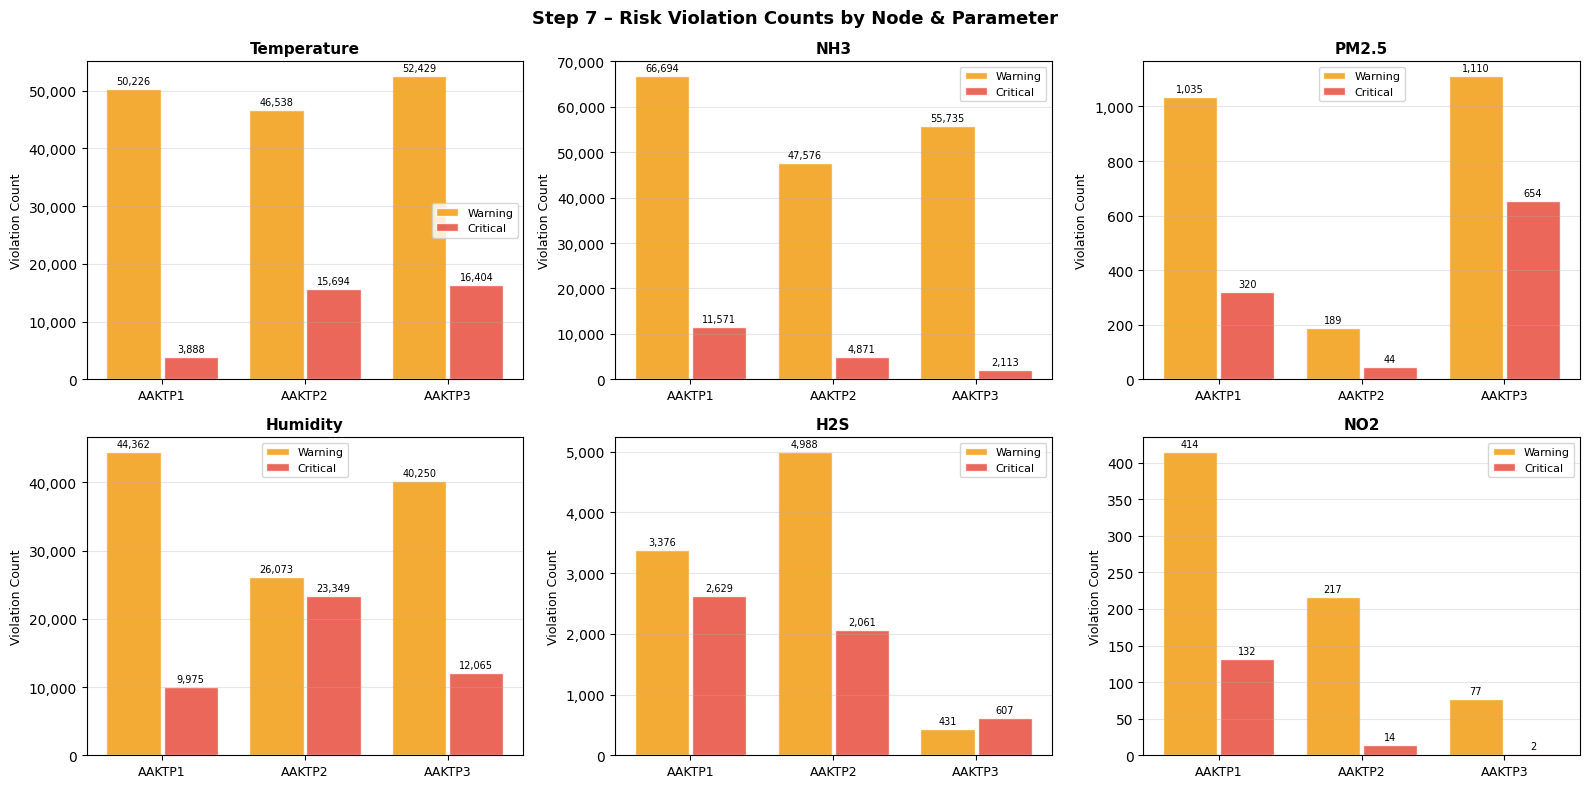

STEP 8 – TEMPORAL ANALYSIS GRAPHS


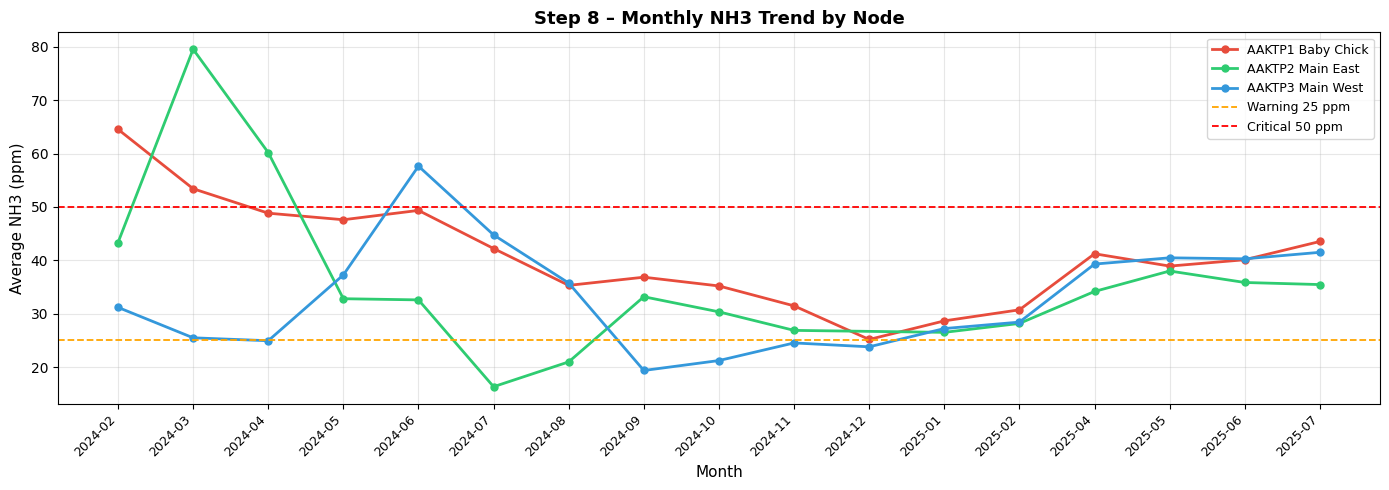

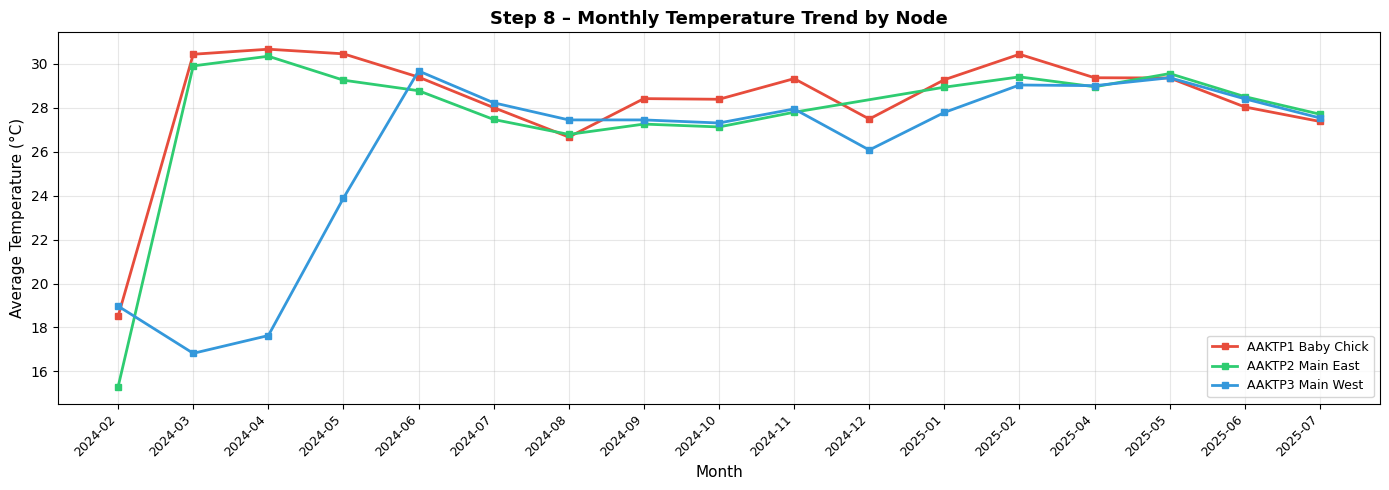

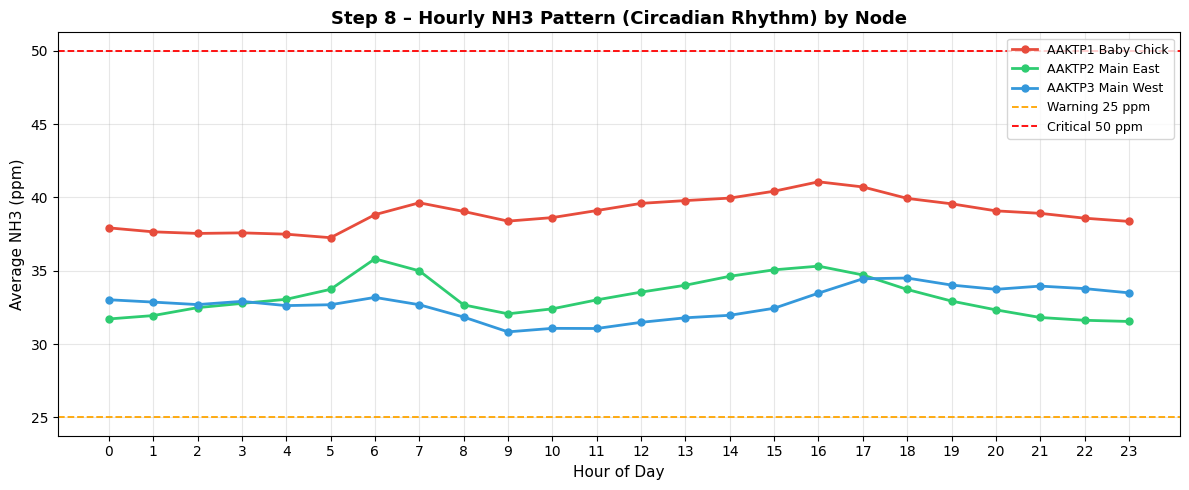

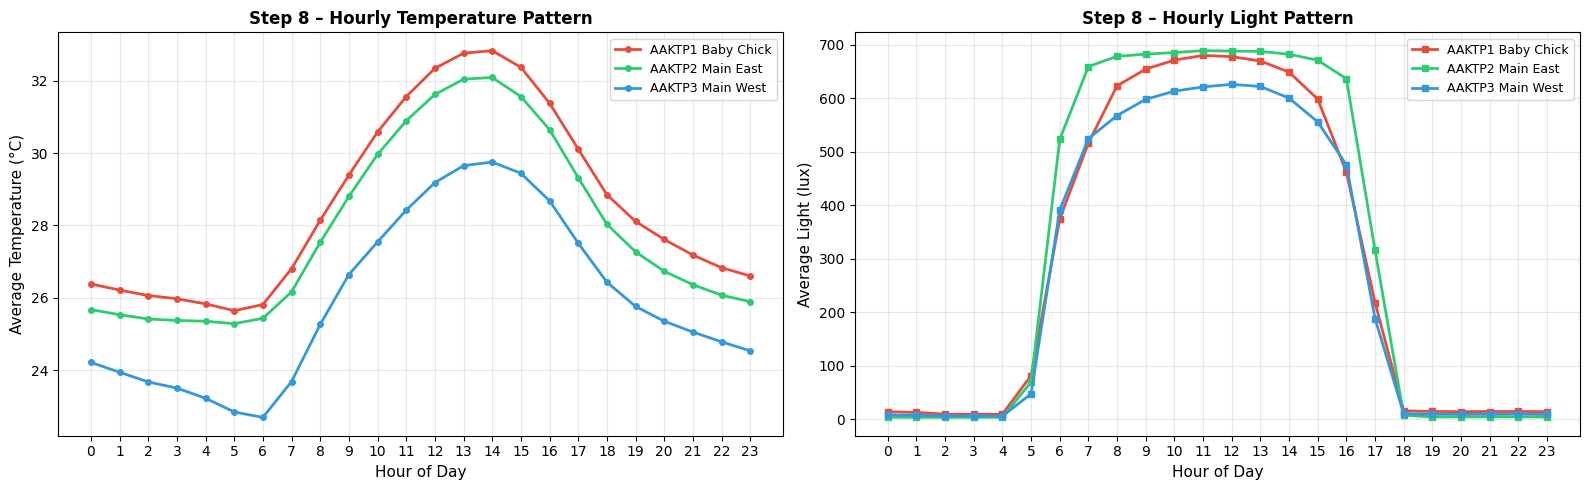


All Step 6, 7 & 8 graphs complete.


In [ ]:
# ============================================================
# VISUALISATIONS – STEPS 6, 7 & 8 (COMBINED GRAPH CELL)
# ============================================================
# Requires: stats_by_node, risk_summary, risk_pct,
#           monthly_trends, hourly_patterns, daily_trends
#           all already computed in Steps 6–8.
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

NODE_COLORS   = {'AAKTP1': '#E74C3C', 'AAKTP2': '#2ECC71', 'AAKTP3': '#3498DB'}
NODE_LABELS   = {'AAKTP1': 'AAKTP1 Baby Chick', 'AAKTP2': 'AAKTP2 Main East', 'AAKTP3': 'AAKTP3 Main West'}

# ── Convert Spark → Pandas ───────────────────────────────────
pd_stats    = stats_by_node.toPandas()
pd_risk     = risk_summary.toPandas()
pd_riskpct  = risk_pct.toPandas()
pd_monthly  = monthly_trends.toPandas()
pd_hourly   = hourly_patterns.toPandas()
pd_daily    = daily_trends.toPandas()

pd_monthly  = pd_monthly.sort_values('MonthYear')
pd_hourly   = pd_hourly.sort_values(['Node', 'Hour'])
pd_daily    = pd_daily.sort_values('Date')

nodes = sorted(pd_stats['Node'].unique())

# ============================================================
# ── STEP 6 GRAPHS ───────────────────────────────────────────
# ============================================================
print('=' * 60)
print('STEP 6 – DESCRIPTIVE STATISTICS GRAPHS')
print('=' * 60)

# ── 6A: Average Key Parameters by Node ──────────────────────
params_6 = ['Avg_Temp', 'Avg_Humidity', 'Avg_NH3', 'Avg_PM2_5',
            'Avg_H2S',  'Avg_NO2',      'Avg_Noise', 'Avg_TVOC']
labels_6 = ['Temp (°C)', 'Humidity (%RH)', 'NH3 (ppm)', 'PM2.5 (µg/m³)',
            'H2S (ppm)', 'NO2 (ppm)',     'Noise (dB)', 'TVOC (ppb)']

n_params  = len(params_6)
x         = np.arange(n_params)
bar_width = 0.25

fig, ax = plt.subplots(figsize=(16, 6))
for i, node in enumerate(nodes):
    row  = pd_stats[pd_stats['Node'] == node].iloc[0]
    vals = [row[p] if p in row.index else 0 for p in params_6]
    bars = ax.bar(x + i * bar_width, vals, bar_width,
                  label=NODE_LABELS[node], color=NODE_COLORS[node], alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f'{val:.1f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x + bar_width)
ax.set_xticklabels(labels_6, fontsize=10)
ax.set_ylabel('Average Value', fontsize=11)
ax.set_title('Step 6 – Average Environmental Parameters by Node', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

# ── 6B: Min / Max Temperature by Node ───────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
for i, node in enumerate(nodes):
    row  = pd_stats[pd_stats['Node'] == node].iloc[0]
    low  = row['Min_Temp']
    high = row['Max_Temp']
    mid  = row['Avg_Temp']
    ax.barh(i, high - low, left=low, height=0.5,
            color=NODE_COLORS[node], alpha=0.7, edgecolor='grey')
    ax.plot(mid, i, 'D', color='black', markersize=7, zorder=5)
    ax.text(high + 0.3, i, f'  avg={mid:.1f}°C', va='center', fontsize=9)

ax.set_yticks(range(len(nodes)))
ax.set_yticklabels([NODE_LABELS[n] for n in nodes], fontsize=10)
ax.set_xlabel('Temperature (°C)', fontsize=11)
ax.set_title('Step 6 – Temperature Range by Node\n(bar = min–max, diamond = mean)',
             fontsize=12, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# ── STEP 7 GRAPHS ───────────────────────────────────────────
# ============================================================
print('=' * 60)
print('STEP 7 – ANOMALY & RISK CONDITION GRAPHS')
print('=' * 60)

# ── 7A: NH3 Risk Distribution (stacked bar) ─────────────────
fig, ax = plt.subplots(figsize=(9, 5))
bar_w = 0.5

for i, node in enumerate(nodes):
    row         = pd_riskpct[pd_riskpct['Node'] == node].iloc[0]
    warn_pct    = float(row['NH3_Warning_Pct'])
    crit_pct    = float(row['NH3_Critical_Pct'])
    danger_pct  = float(row['NH3_HumanDanger_Pct'])
    safe_pct    = 100 - warn_pct - crit_pct - danger_pct

    ax.bar(i, safe_pct,   bar_w, label='Safe'                  if i == 0 else '', color='#2ECC71', alpha=0.85)
    ax.bar(i, warn_pct,   bar_w, bottom=safe_pct,               label='Warning (>25 ppm)'      if i == 0 else '', color='#F39C12', alpha=0.85)
    ax.bar(i, crit_pct,   bar_w, bottom=safe_pct + warn_pct,    label='Critical (>50 ppm)'     if i == 0 else '', color='#E74C3C', alpha=0.85)
    ax.bar(i, danger_pct, bar_w, bottom=safe_pct + warn_pct + crit_pct, label='Human Danger (>100 ppm)' if i == 0 else '', color='#6C3483', alpha=0.85)

    for level, bottom, pct in [
        ('Safe',    0,                              safe_pct),
        ('Warning', safe_pct,                       warn_pct),
        ('Critical',safe_pct + warn_pct,            crit_pct),
        ('Danger',  safe_pct + warn_pct + crit_pct, danger_pct),
    ]:
        if pct > 1.5:
            ax.text(i, bottom + pct / 2, f'{pct:.1f}%', ha='center', va='center',
                    fontsize=9, fontweight='bold', color='white')

ax.set_xticks(range(len(nodes)))
ax.set_xticklabels([NODE_LABELS[n] for n in nodes], fontsize=10)
ax.set_ylabel('% of Total Readings', fontsize=11)
ax.set_ylim(0, 100)
ax.set_title('Step 7 – NH3 Risk Distribution by Node', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ── 7B: Multi-Parameter Risk Violation Counts ───────────────
risk_pairs = [
    ('Temp_Critical',     'Temp_Warning',    'Temperature'),
    ('NH3_Critical',      'NH3_Warning',     'NH3'),
    ('PM25_Critical',     'PM25_Warning',    'PM2.5'),
    ('Humidity_Critical', 'Humidity_Warning','Humidity'),
    ('H2S_Critical',      'H2S_Warning',     'H2S'),
    ('NO2_Critical',      'NO2_Warning',     'NO2'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Step 7 – Risk Violation Counts by Node & Parameter',
             fontsize=13, fontweight='bold')

for idx, (crit_col, warn_col, param_name) in enumerate(risk_pairs):
    ax    = axes[idx // 3][idx % 3]
    xpos  = np.arange(len(nodes))
    warn_vals = [float(pd_risk[pd_risk['Node'] == n][warn_col].values[0]) if len(pd_risk[pd_risk['Node'] == n]) else 0 for n in nodes]
    crit_vals = [float(pd_risk[pd_risk['Node'] == n][crit_col].values[0]) if len(pd_risk[pd_risk['Node'] == n]) else 0 for n in nodes]

    ax.bar(xpos - 0.2, warn_vals, 0.38, label='Warning',  color='#F39C12', alpha=0.85, edgecolor='white')
    ax.bar(xpos + 0.2, crit_vals, 0.38, label='Critical', color='#E74C3C', alpha=0.85, edgecolor='white')

    combined_max = np.max(warn_vals + crit_vals)   # np.max avoids PySpark conflict
    for xi, (w, c) in enumerate(zip(warn_vals, crit_vals)):
        if w > 0: ax.text(xi - 0.2, w + combined_max * 0.01, f'{int(w):,}', ha='center', va='bottom', fontsize=7)
        if c > 0: ax.text(xi + 0.2, c + combined_max * 0.01, f'{int(c):,}', ha='center', va='bottom', fontsize=7)

    ax.set_xticks(xpos)
    ax.set_xticklabels(nodes, fontsize=9)
    ax.set_title(param_name, fontsize=11, fontweight='bold')
    ax.set_ylabel('Violation Count', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, axis='y', alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

# ============================================================
# ── STEP 8 GRAPHS ───────────────────────────────────────────
# ============================================================
print('=' * 60)
print('STEP 8 – TEMPORAL ANALYSIS GRAPHS')
print('=' * 60)

# ── 8A: Monthly Average NH3 Trend ───────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
for node in nodes:
    df_n = pd_monthly[pd_monthly['Node'] == node].sort_values('MonthYear')
    ax.plot(df_n['MonthYear'], df_n['Avg_NH3'], marker='o', linewidth=2,
            markersize=5, label=NODE_LABELS[node], color=NODE_COLORS[node])

ax.axhline(y=25, color='orange', linestyle='--', linewidth=1.3, label='Warning 25 ppm')
ax.axhline(y=50, color='red',    linestyle='--', linewidth=1.3, label='Critical 50 ppm')
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Average NH3 (ppm)', fontsize=11)
ax.set_title('Step 8 – Monthly NH3 Trend by Node', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

# ── 8B: Monthly Average Temperature Trend ───────────────────
fig, ax = plt.subplots(figsize=(14, 5))
for node in nodes:
    df_n = pd_monthly[pd_monthly['Node'] == node].sort_values('MonthYear')
    ax.plot(df_n['MonthYear'], df_n['Avg_Temp'], marker='s', linewidth=2,
            markersize=5, label=NODE_LABELS[node], color=NODE_COLORS[node])

ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Average Temperature (°C)', fontsize=11)
ax.set_title('Step 8 – Monthly Temperature Trend by Node', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

# ── 8C: Hourly NH3 Pattern (Circadian) ──────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
for node in nodes:
    df_n = pd_hourly[pd_hourly['Node'] == node].sort_values('Hour')
    ax.plot(df_n['Hour'], df_n['Avg_NH3'], marker='o', linewidth=2,
            markersize=5, label=NODE_LABELS[node], color=NODE_COLORS[node])

ax.axhline(y=25, color='orange', linestyle='--', linewidth=1.3, label='Warning 25 ppm')
ax.axhline(y=50, color='red',    linestyle='--', linewidth=1.3, label='Critical 50 ppm')
ax.set_xticks(range(0, 24))
ax.set_xlabel('Hour of Day', fontsize=11)
ax.set_ylabel('Average NH3 (ppm)', fontsize=11)
ax.set_title('Step 8 – Hourly NH3 Pattern (Circadian Rhythm) by Node',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── 8D: Hourly Temperature & Light Pattern ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for node in nodes:
    df_n = pd_hourly[pd_hourly['Node'] == node].sort_values('Hour')
    axes[0].plot(df_n['Hour'], df_n['Avg_Temp'],  marker='o', linewidth=2, markersize=4,
                 label=NODE_LABELS[node], color=NODE_COLORS[node])
    axes[1].plot(df_n['Hour'], df_n['Avg_Light'], marker='s', linewidth=2, markersize=4,
                 label=NODE_LABELS[node], color=NODE_COLORS[node])

for a, title, ylabel in [
    (axes[0], 'Hourly Temperature Pattern', 'Average Temperature (°C)'),
    (axes[1], 'Hourly Light Pattern',       'Average Light (lux)'),
]:
    a.set_xticks(range(0, 24))
    a.set_xlabel('Hour of Day', fontsize=11)
    a.set_ylabel(ylabel, fontsize=11)
    a.set_title(f'Step 8 – {title}', fontsize=12, fontweight='bold')
    a.legend(fontsize=9)
    a.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

"""
# ── 8E: Daily NH3 Violations Over Time ──────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
for node in nodes:
    df_n = pd_daily[pd_daily['Node'] == node].sort_values('Date')
    ax.plot(df_n['Date'], df_n['NH3_Violations'], linewidth=1.5,
            label=NODE_LABELS[node], color=NODE_COLORS[node], alpha=0.85)

ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('NH3 Violations per Day (>50 ppm)', fontsize=11)
ax.set_title('Step 8 – Daily NH3 Critical Violations Over Time',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
all_dates = sorted(pd_daily['Date'].unique())
tick_step = np.max([1, len(all_dates) // 20])   # np.max avoids PySpark conflict
ax.set_xticks(all_dates[::tick_step])
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()
"""

print('\nAll Step 6, 7 & 8 graphs complete.')

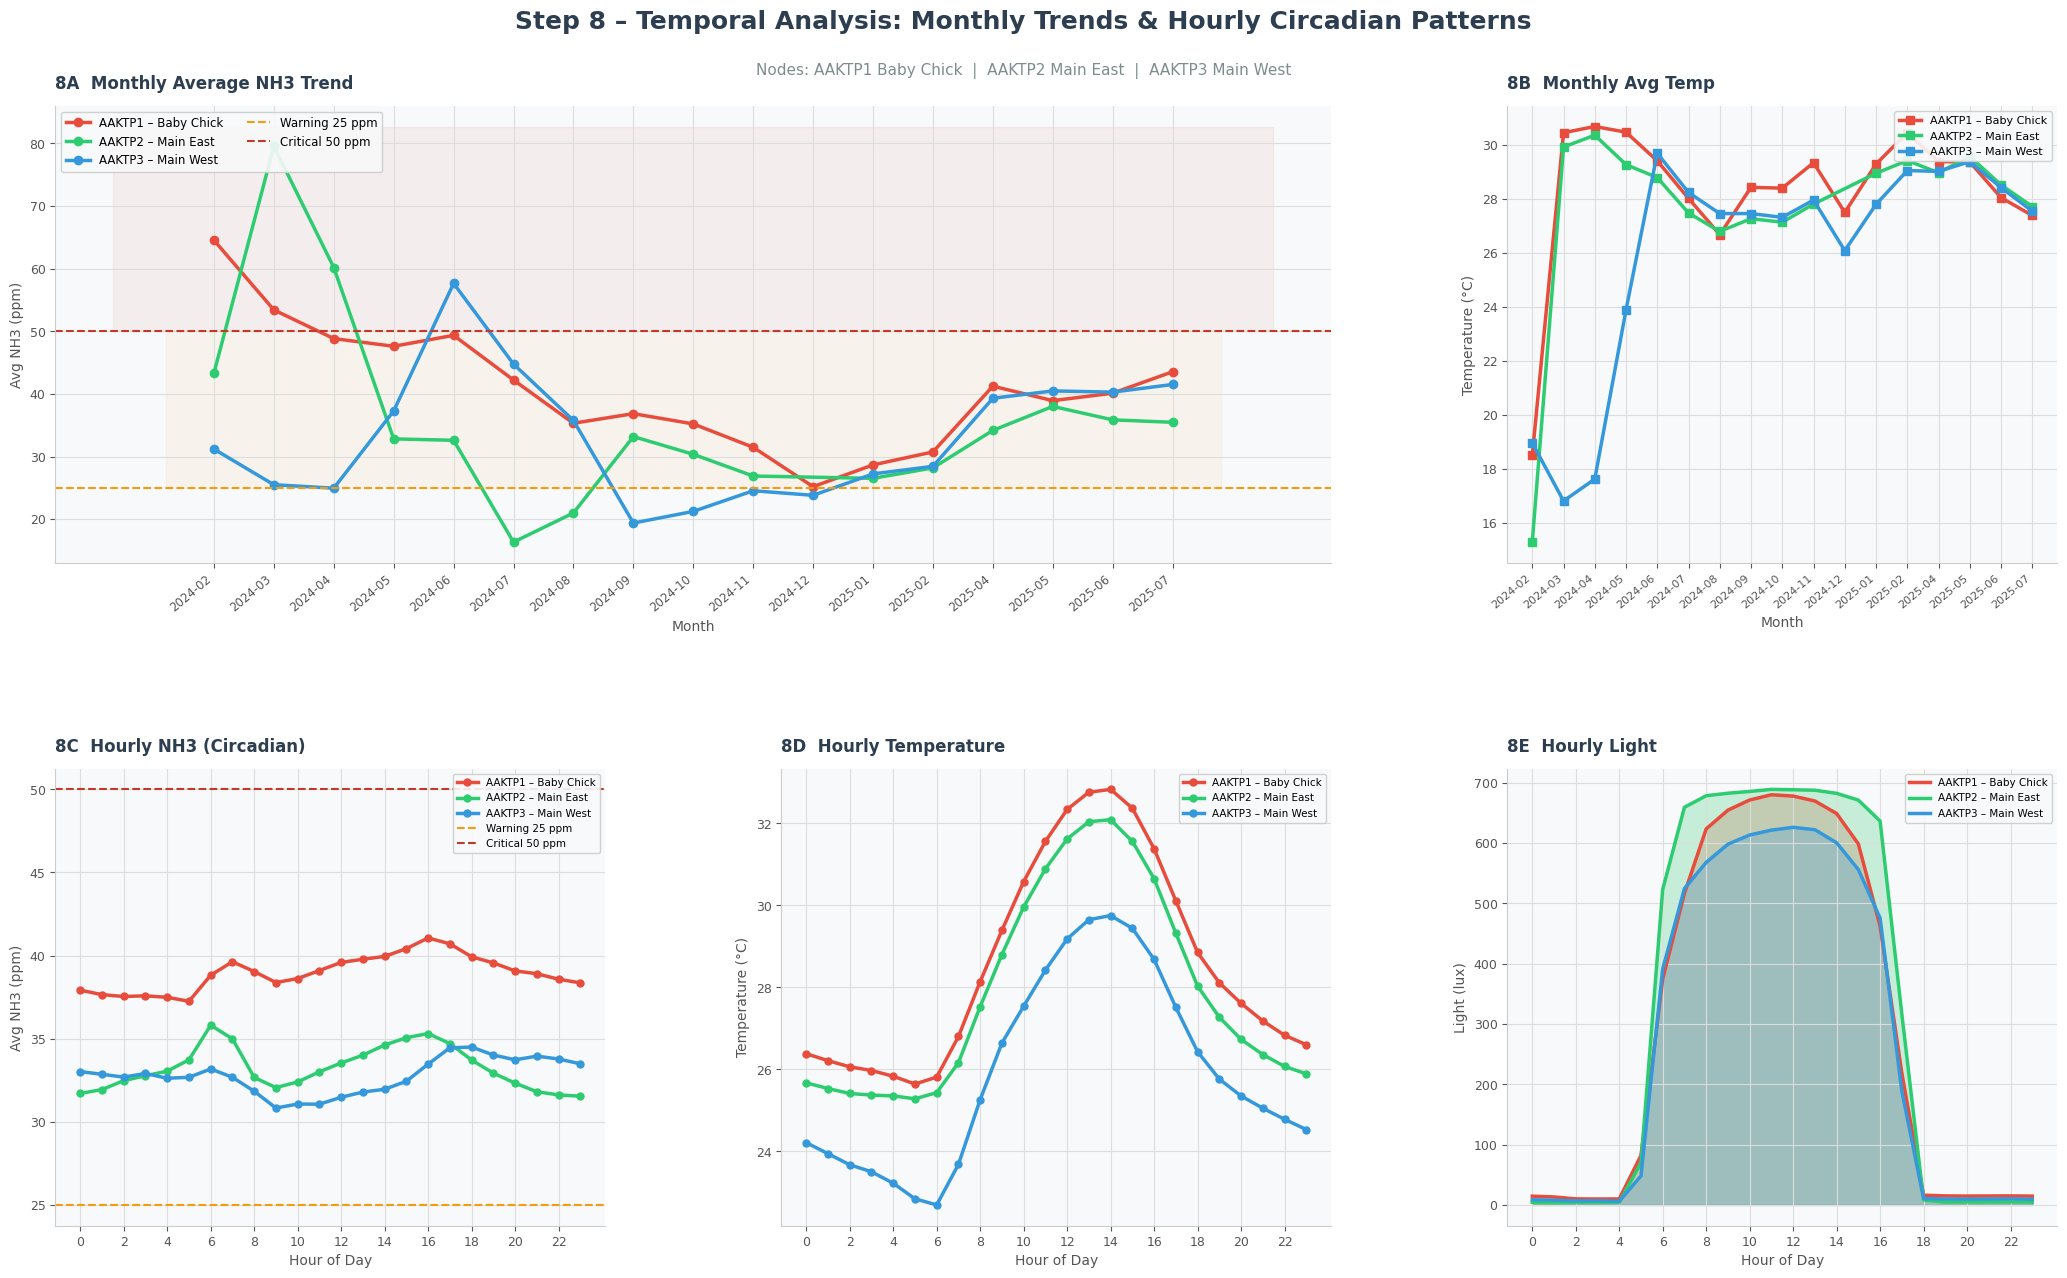

Step 8 combined figure complete.


In [ ]:
# ============================================================
# STEP 8 – ALL TEMPORAL GRAPHS IN ONE POWERPOINT-READY FIGURE
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import numpy as np

# ── Style setup ─────────────────────────────────────────────
plt.rcParams.update({
    'font.family':      'DejaVu Sans',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.facecolor':   '#F8F9FA',
    'figure.facecolor': '#FFFFFF',
    'axes.grid':        True,
    'grid.color':       '#DDDDDD',
    'grid.linewidth':   0.8,
    'axes.titlepad':    12,
})

NODE_COLORS  = {'AAKTP1': '#E74C3C', 'AAKTP2': '#2ECC71', 'AAKTP3': '#3498DB'}
NODE_LABELS  = {'AAKTP1': 'AAKTP1 – Baby Chick', 'AAKTP2': 'AAKTP2 – Main East', 'AAKTP3': 'AAKTP3 – Main West'}
WARN_COLOR   = '#F39C12'
CRIT_COLOR   = '#C0392B'

nodes = sorted(pd_monthly['Node'].unique())

# ── Figure & GridSpec ────────────────────────────────────────
fig = plt.figure(figsize=(22, 14))
fig.patch.set_facecolor('#FFFFFF')

gs = gridspec.GridSpec(
    2, 3,
    figure=fig,
    hspace=0.45,
    wspace=0.32,
    left=0.06, right=0.97,
    top=0.88,  bottom=0.08
)

ax_nh3_monthly  = fig.add_subplot(gs[0, :2])   # top-left, spans 2 cols
ax_temp_monthly = fig.add_subplot(gs[0, 2])    # top-right
ax_nh3_hourly   = fig.add_subplot(gs[1, 0])    # bottom-left
ax_temp_hourly  = fig.add_subplot(gs[1, 1])    # bottom-mid
ax_light_hourly = fig.add_subplot(gs[1, 2])    # bottom-right

# ── Main title ───────────────────────────────────────────────
fig.text(
    0.5, 0.94,
    'Step 8 – Temporal Analysis: Monthly Trends & Hourly Circadian Patterns',
    ha='center', va='center',
    fontsize=18, fontweight='bold', color='#2C3E50'
)
fig.text(
    0.5, 0.905,
    'Nodes: AAKTP1 Baby Chick  |  AAKTP2 Main East  |  AAKTP3 Main West',
    ha='center', va='center',
    fontsize=11, color='#7F8C8D'
)

# ── Helper: style an axis ────────────────────────────────────
def style_ax(ax, title, xlabel, ylabel, title_color='#2C3E50'):
    ax.set_title(title, fontsize=12, fontweight='bold', color=title_color, loc='left')
    ax.set_xlabel(xlabel, fontsize=10, color='#555555')
    ax.set_ylabel(ylabel, fontsize=10, color='#555555')
    ax.tick_params(colors='#555555', labelsize=9)
    ax.set_facecolor('#F8F9FA')
    for spine in ax.spines.values():
        spine.set_edgecolor('#CCCCCC')

# ── 8A: Monthly NH3 Trend (wide) ────────────────────────────
for node in nodes:
    df_n = pd_monthly[pd_monthly['Node'] == node].sort_values('MonthYear')
    ax_nh3_monthly.plot(
        df_n['MonthYear'], df_n['Avg_NH3'],
        marker='o', linewidth=2.5, markersize=6,
        label=NODE_LABELS[node], color=NODE_COLORS[node]
    )

ax_nh3_monthly.axhline(y=25, color=WARN_COLOR, linestyle='--', linewidth=1.5, label='Warning 25 ppm')
ax_nh3_monthly.axhline(y=50, color=CRIT_COLOR, linestyle='--', linewidth=1.5, label='Critical 50 ppm')
ax_nh3_monthly.fill_between(
    ax_nh3_monthly.get_xlim(), 25, 50, alpha=0.06, color=WARN_COLOR
)
ax_nh3_monthly.fill_between(
    ax_nh3_monthly.get_xlim(), 50, ax_nh3_monthly.get_ylim()[1] if ax_nh3_monthly.get_ylim()[1] > 50 else 55,
    alpha=0.06, color=CRIT_COLOR
)
ax_nh3_monthly.legend(fontsize=8.5, framealpha=0.9, loc='upper left', ncol=2)
style_ax(ax_nh3_monthly, '8A  Monthly Average NH3 Trend', 'Month', 'Avg NH3 (ppm)')
plt.setp(ax_nh3_monthly.get_xticklabels(), rotation=40, ha='right', fontsize=8.5)

# ── 8B: Monthly Temperature Trend ───────────────────────────
for node in nodes:
    df_n = pd_monthly[pd_monthly['Node'] == node].sort_values('MonthYear')
    ax_temp_monthly.plot(
        df_n['MonthYear'], df_n['Avg_Temp'],
        marker='s', linewidth=2.5, markersize=6,
        label=NODE_LABELS[node], color=NODE_COLORS[node]
    )

ax_temp_monthly.legend(fontsize=8, framealpha=0.9, loc='upper right')
style_ax(ax_temp_monthly, '8B  Monthly Avg Temp', 'Month', 'Temperature (°C)')
plt.setp(ax_temp_monthly.get_xticklabels(), rotation=40, ha='right', fontsize=8)

# ── 8C: Hourly NH3 Circadian ────────────────────────────────
for node in nodes:
    df_n = pd_hourly[pd_hourly['Node'] == node].sort_values('Hour')
    ax_nh3_hourly.plot(
        df_n['Hour'], df_n['Avg_NH3'],
        marker='o', linewidth=2.5, markersize=5,
        label=NODE_LABELS[node], color=NODE_COLORS[node]
    )

ax_nh3_hourly.axhline(y=25, color=WARN_COLOR, linestyle='--', linewidth=1.5, label='Warning 25 ppm')
ax_nh3_hourly.axhline(y=50, color=CRIT_COLOR, linestyle='--', linewidth=1.5, label='Critical 50 ppm')
ax_nh3_hourly.set_xticks(range(0, 24, 2))
ax_nh3_hourly.legend(fontsize=7.5, framealpha=0.9, ncol=1)
style_ax(ax_nh3_hourly, '8C  Hourly NH3 (Circadian)', 'Hour of Day', 'Avg NH3 (ppm)')

# ── 8D: Hourly Temperature ───────────────────────────────────
for node in nodes:
    df_n = pd_hourly[pd_hourly['Node'] == node].sort_values('Hour')
    ax_temp_hourly.plot(
        df_n['Hour'], df_n['Avg_Temp'],
        marker='o', linewidth=2.5, markersize=5,
        label=NODE_LABELS[node], color=NODE_COLORS[node]
    )

ax_temp_hourly.set_xticks(range(0, 24, 2))
ax_temp_hourly.legend(fontsize=7.5, framealpha=0.9)
style_ax(ax_temp_hourly, '8D  Hourly Temperature', 'Hour of Day', 'Temperature (°C)')

# ── 8E: Hourly Light ─────────────────────────────────────────
for node in nodes:
    df_n = pd_hourly[pd_hourly['Node'] == node].sort_values('Hour')
    ax_light_hourly.fill_between(
        df_n['Hour'], df_n['Avg_Light'],
        alpha=0.25, color=NODE_COLORS[node]
    )
    ax_light_hourly.plot(
        df_n['Hour'], df_n['Avg_Light'],
        linewidth=2.5, markersize=5,
        label=NODE_LABELS[node], color=NODE_COLORS[node]
    )

ax_light_hourly.set_xticks(range(0, 24, 2))
ax_light_hourly.legend(fontsize=7.5, framealpha=0.9)
style_ax(ax_light_hourly, '8E  Hourly Light', 'Hour of Day', 'Light (lux)')

plt.show()
print('Step 8 combined figure complete.')

## Step 12 – Visualisations
Environmental data is visualised in two parts. **12A** plots individual node trends over the full 17-month period for temperature, humidity, and NH3 — with threshold reference lines shown on the NH3 plots. **12B** produces comparative charts across all three nodes including a 6-panel average metrics bar chart, a stacked NH3 risk distribution bar chart, a correlation heatmap, a monthly NH3 trend line chart, and an overall compliance pie chart.


12A. VISUALISATIONS: ENVIRONMENTAL TRENDS BY INDIVIDUAL NODE



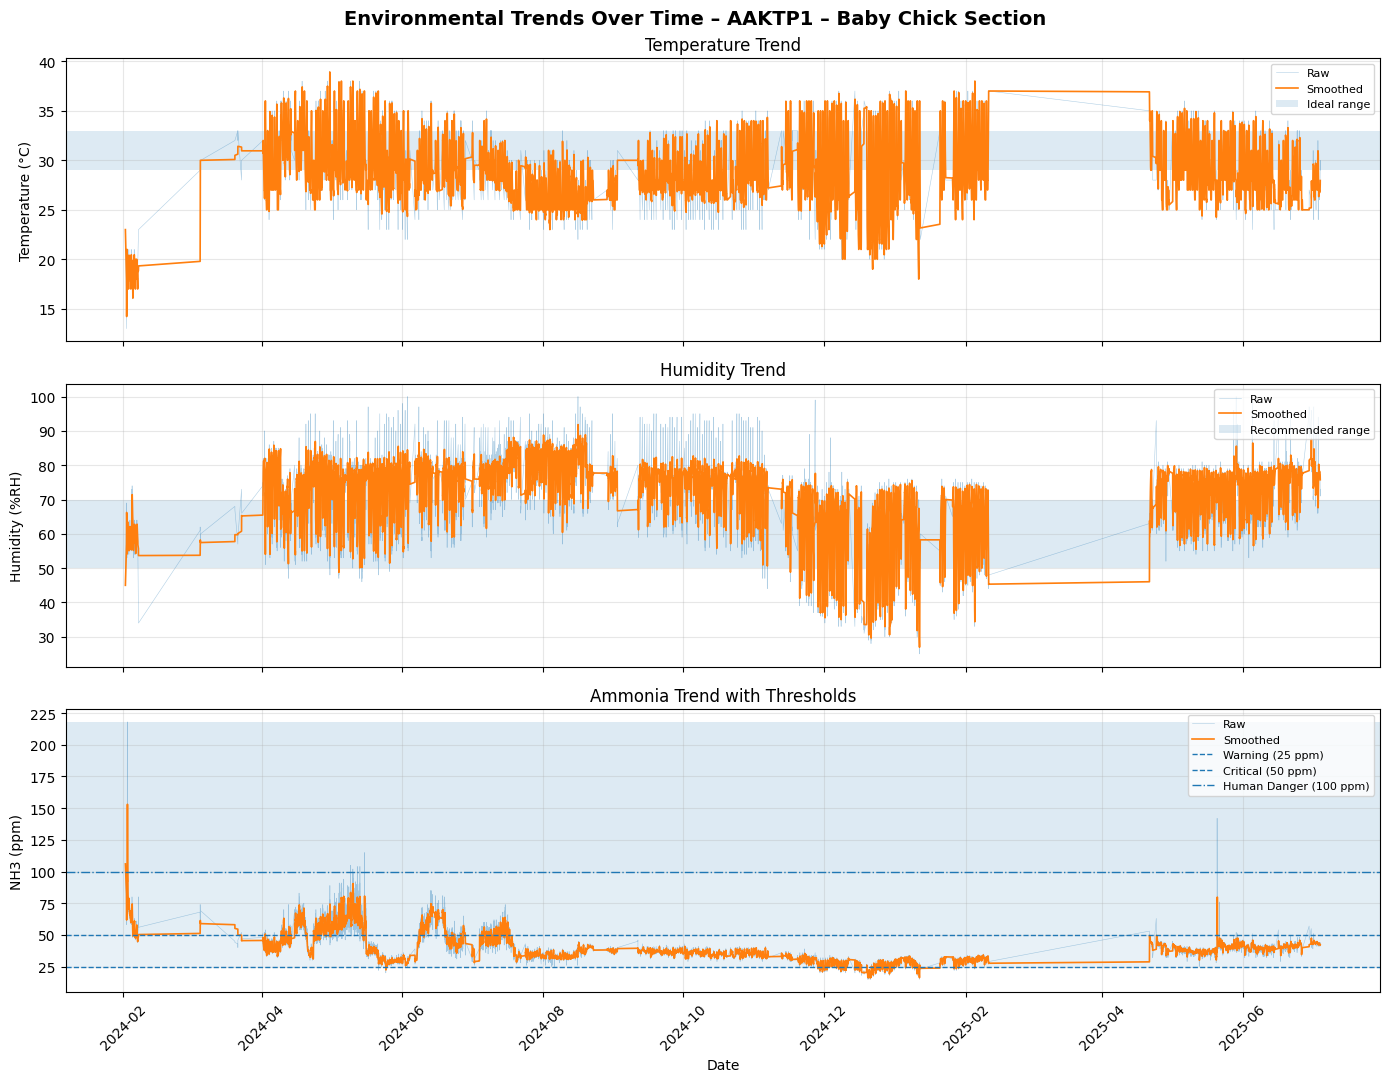


Summary for AAKTP1 – Baby Chick Section:
  Avg Temperature: 28.74 °C
  Avg Humidity   : 70.96 %RH
  Avg NH3        : 39.02 ppm
  Max NH3        : 218.00 ppm
  NH3 > 25 ppm   : 94.34% of readings
  NH3 > 50 ppm   : 14.04% of readings


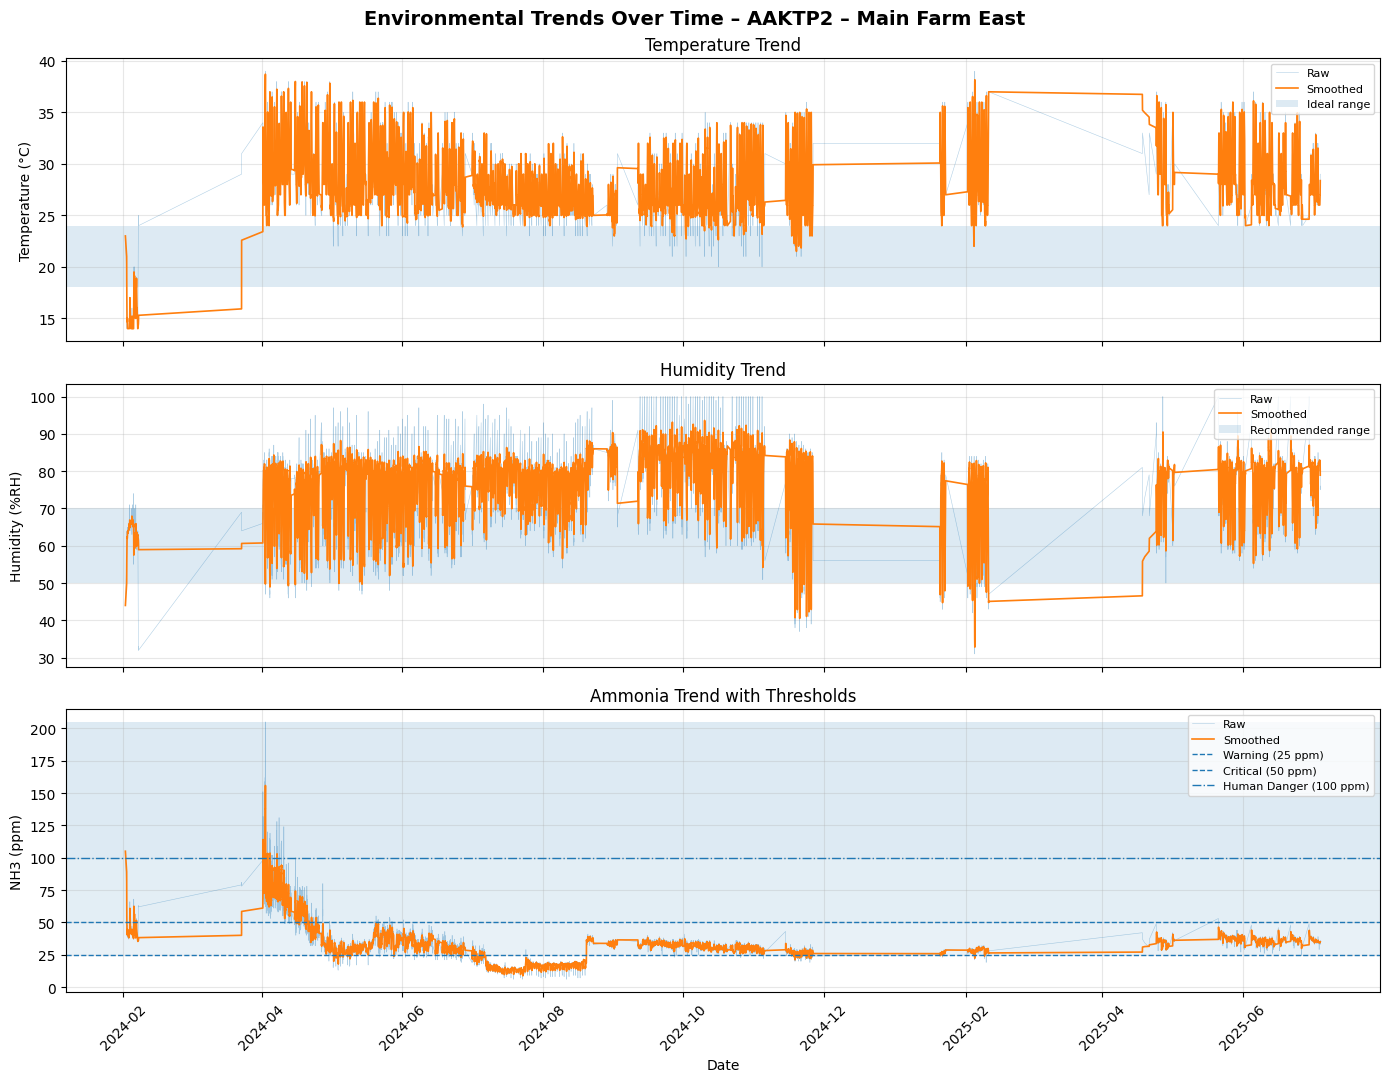


Summary for AAKTP2 – Main Farm East:
  Avg Temperature: 28.10 °C
  Avg Humidity   : 75.54 %RH
  Avg NH3        : 33.17 ppm
  Max NH3        : 205.00 ppm
  NH3 > 25 ppm   : 79.88% of readings
  NH3 > 50 ppm   : 7.78% of readings


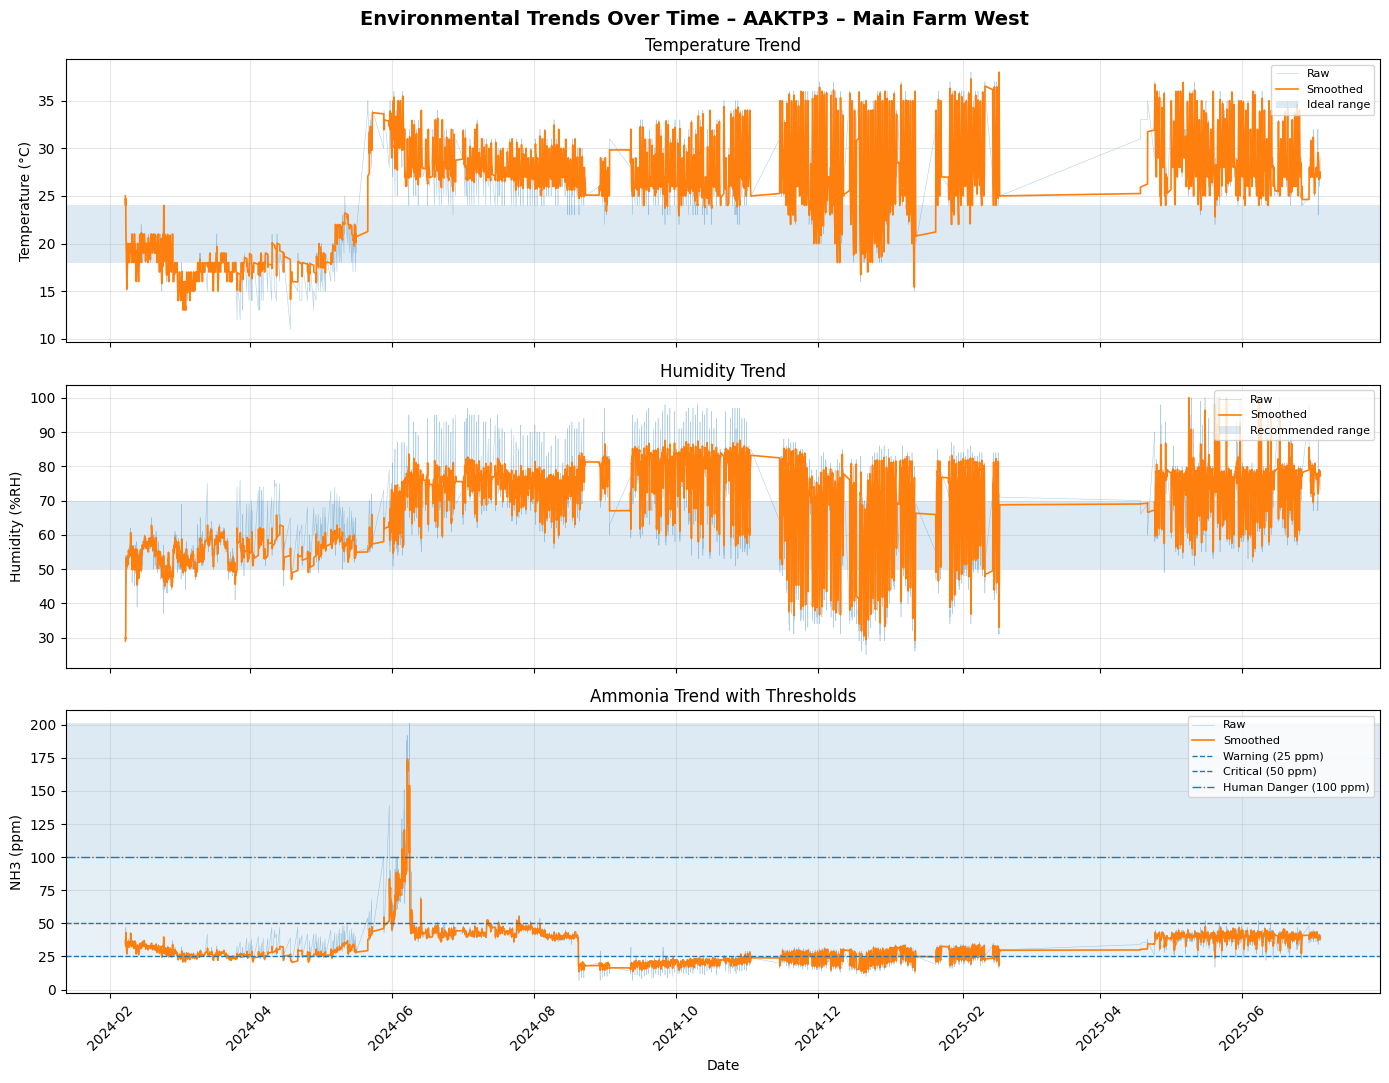


Summary for AAKTP3 – Main Farm West:
  Avg Temperature: 26.09 °C
  Avg Humidity   : 68.55 %RH
  Avg NH3        : 32.78 ppm
  Max NH3        : 201.00 ppm
  NH3 > 25 ppm   : 67.61% of readings
  NH3 > 50 ppm   : 2.90% of readings

Individual node visualisations completed successfully.


In [ ]:
print('\n' + '=' * 70)
print('12A. VISUALISATIONS: ENVIRONMENTAL TRENDS BY INDIVIDUAL NODE')
print('=' * 70 + '\n')

from pyspark.sql.functions import col, to_timestamp
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import builtins


# 1. Ensure robust timestamp parsing

def ensure_timestamp(df):
    if 'Timestamp' not in df.columns:
        df = df.withColumn('Timestamp', to_timestamp(col('Time'), 'd/M/yyyy H:mm'))
    return df.filter(col('Timestamp').isNotNull())


# 2. Convert Spark DataFrames to Pandas

pd_node1 = ensure_timestamp(
    node1_clean.select('Time', 'Temperature', 'Humidity', 'NH3', 'Node')
).toPandas()

pd_node2 = ensure_timestamp(
    node2_clean.select('Time', 'Temperature', 'Humidity', 'NH3', 'Node')
).toPandas()

pd_node3 = ensure_timestamp(
    node3_clean.select('Time', 'Temperature', 'Humidity', 'NH3', 'Node')
).toPandas()

# 3. Plotting helper

def plot_node_trends(df, node_name):
    df = df.copy()
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
    df = df.dropna(subset=['Timestamp']).sort_values('Timestamp')

    # Optional smoothing to make 17-month trends readable
    df['Temp_Smoothed'] = df['Temperature'].rolling(window=24, min_periods=1).mean()
    df['Humidity_Smoothed'] = df['Humidity'].rolling(window=24, min_periods=1).mean()
    df['NH3_Smoothed'] = df['NH3'].rolling(window=24, min_periods=1).mean()

    fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
    fig.suptitle(f'Environmental Trends Over Time – {node_name}', fontsize=14, fontweight='bold')

    # Temperature
    axes[0].plot(df['Timestamp'], df['Temperature'], linewidth=0.4, alpha=0.35, label='Raw')
    axes[0].plot(df['Timestamp'], df['Temp_Smoothed'], linewidth=1.2, label='Smoothed')
    axes[0].set_ylabel('Temperature (°C)')
    axes[0].set_title('Temperature Trend')
    axes[0].grid(True, alpha=0.3)

    # Add ideal ranges depending on node
    if 'AAKTP1' in node_name or 'Baby Chick' in node_name:
        axes[0].axhspan(29, 33, alpha=0.15, label='Ideal range')
    else:
        axes[0].axhspan(18, 24, alpha=0.15, label='Ideal range')

    axes[0].legend(fontsize=8, loc='upper right')


    # Humidity

    axes[1].plot(df['Timestamp'], df['Humidity'], linewidth=0.4, alpha=0.35, label='Raw')
    axes[1].plot(df['Timestamp'], df['Humidity_Smoothed'], linewidth=1.2, label='Smoothed')
    axes[1].axhspan(50, 70, alpha=0.15, label='Recommended range')
    axes[1].set_ylabel('Humidity (%RH)')
    axes[1].set_title('Humidity Trend')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(fontsize=8, loc='upper right')


    # NH3

    axes[2].plot(df['Timestamp'], df['NH3'], linewidth=0.4, alpha=0.35, label='Raw')
    axes[2].plot(df['Timestamp'], df['NH3_Smoothed'], linewidth=1.2, label='Smoothed')

    axes[2].axhline(25, linestyle='--', linewidth=1, label='Warning (25 ppm)')
    axes[2].axhline(50, linestyle='--', linewidth=1, label='Critical (50 ppm)')
    axes[2].axhline(100, linestyle='-.', linewidth=1, label='Human Danger (100 ppm)')

    nh3_upper = builtins.max(float(df['NH3'].max()), 110.0)

    axes[2].axhspan(25, 50, alpha=0.10)
    axes[2].axhspan(50, 100, alpha=0.12)
    axes[2].axhspan(100, nh3_upper, alpha=0.15)

    axes[2].set_ylabel('NH3 (ppm)')
    axes[2].set_title('Ammonia Trend with Thresholds')
    axes[2].grid(True, alpha=0.3)
    axes[2].legend(fontsize=8, loc='upper right')


    # X-axis formatting

    axes[2].set_xlabel('Date')
    axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


    # Short analytical summary

    print(f"\nSummary for {node_name}:")
    print(f"  Avg Temperature: {df['Temperature'].mean():.2f} °C")
    print(f"  Avg Humidity   : {df['Humidity'].mean():.2f} %RH")
    print(f"  Avg NH3        : {df['NH3'].mean():.2f} ppm")
    print(f"  Max NH3        : {df['NH3'].max():.2f} ppm")
    print(f"  NH3 > 25 ppm   : {(df['NH3'] > 25).mean() * 100:.2f}% of readings")
    print(f"  NH3 > 50 ppm   : {(df['NH3'] > 50).mean() * 100:.2f}% of readings")

# 4. Generate plots for each node

plot_node_trends(pd_node1, 'AAKTP1 – Baby Chick Section')
plot_node_trends(pd_node2, 'AAKTP2 – Main Farm East')
plot_node_trends(pd_node3, 'AAKTP3 – Main Farm West')

print('\nIndividual node visualisations completed successfully.')

### 12B – Comparative Charts Across All Three Nodes


12B. VISUALISATIONS: COMPARATIVE CHARTS ACROSS ALL THREE NODES



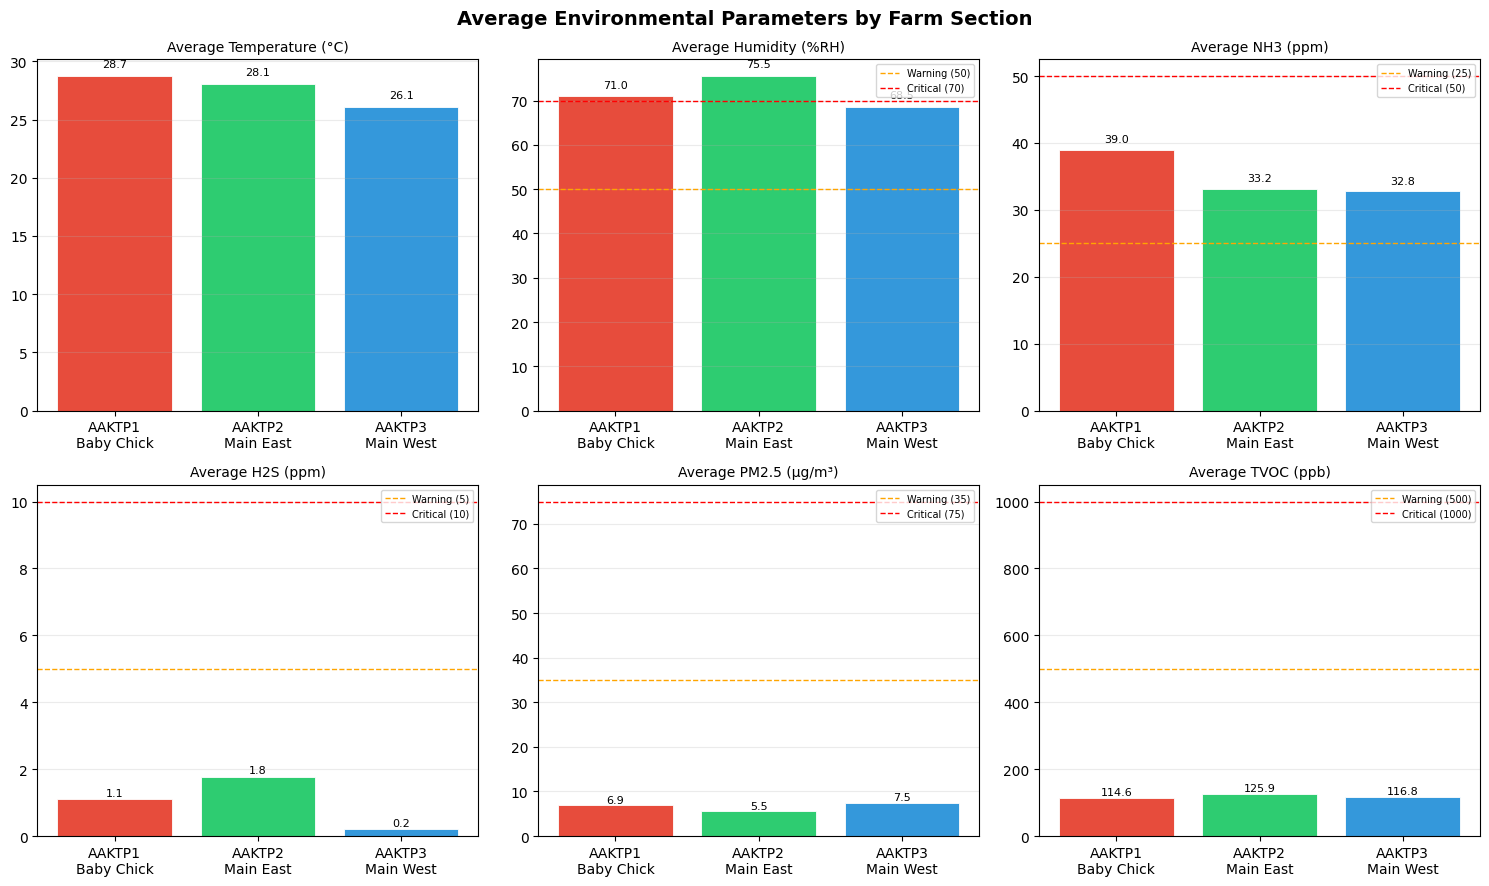

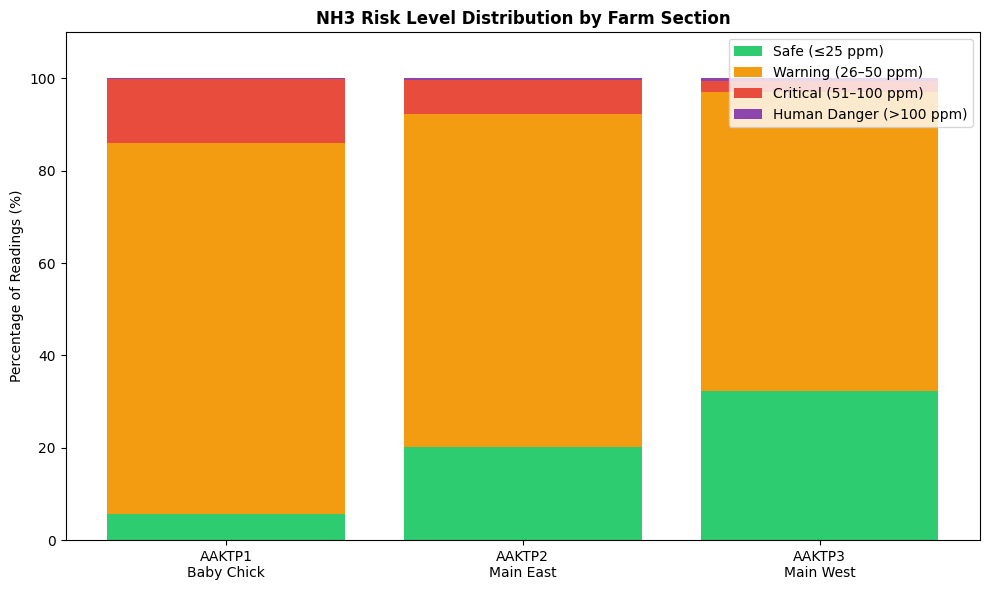

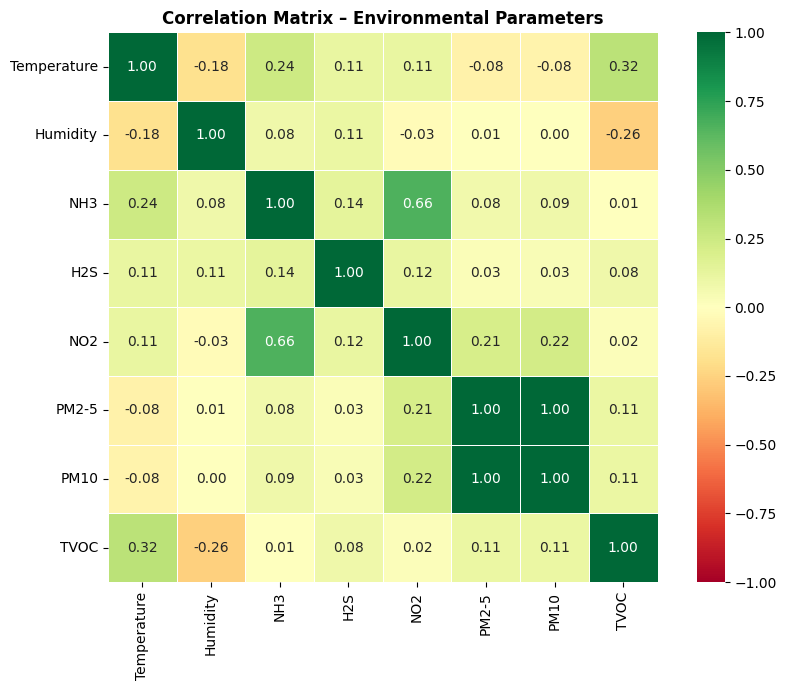

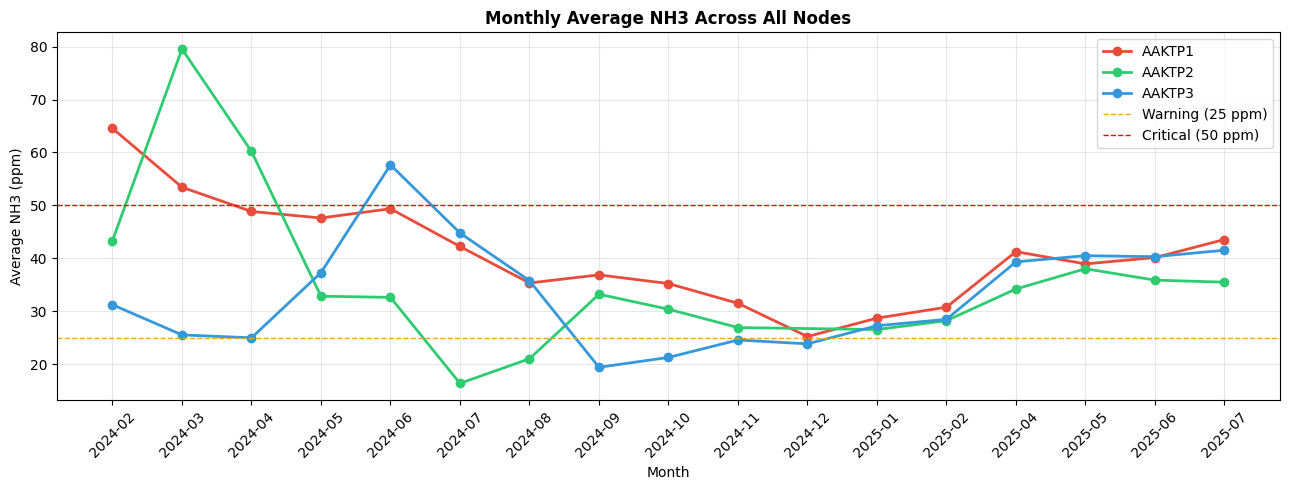

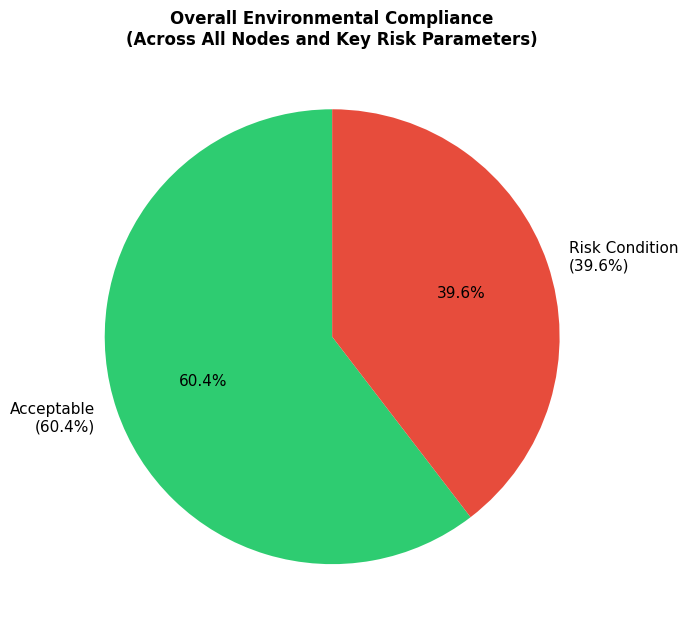


INTERPRETATION SUMMARY
--------------------------------------------------
AAKTP1 requires the most sensitive environmental control due to chick vulnerability.
NH3 is the dominant air-quality risk factor across the farm.
PM2.5 and NH3 patterns suggest ventilation and waste-management issues.
Cross-node variation indicates uneven environmental control performance.

All comparative visualisations generated successfully.


In [ ]:
print('\n' + '=' * 70)
print('12B. VISUALISATIONS: COMPARATIVE CHARTS ACROSS ALL THREE NODES')
print('=' * 70 + '\n')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import builtins

from pyspark.sql.functions import (
    to_timestamp, to_date, hour, date_format,
    avg, stddev, count, sum, when, round, col
)
from pyspark.sql.functions import max as spark_max

# 1. SAFE TREND DATASET
all_nodes_for_trends = (
    node1_clean.unionByName(node2_clean).unionByName(node3_clean)
    .withColumn('Timestamp', to_timestamp(col('Time'), 'd/M/yyyy H:mm'))
    .filter(col('Timestamp').isNotNull())
    .withColumn('MonthYear', date_format(col('Timestamp'), 'yyyy-MM'))
    .withColumn('Hour', hour(col('Timestamp')))
    .withColumn('Date', to_date(col('Timestamp')))
    .withColumnRenamed('PM2-5', 'PM2_5')
    .withColumnRenamed('Noise-Avg', 'Noise_Avg')
    .withColumnRenamed('Noise-Peak', 'Noise_Peak')
)

# 2. MONTHLY TRENDS
monthly_trends = all_nodes_for_trends.groupBy('Node', 'MonthYear').agg(
    count('*').alias('Readings'),
    round(avg('Temperature'), 2).alias('Avg_Temp'),
    round(avg('Humidity'), 2).alias('Avg_Humidity'),
    round(avg('NH3'), 2).alias('Avg_NH3'),
    round(avg('PM2_5'), 2).alias('Avg_PM2_5'),
    spark_max('NH3').alias('Max_NH3'),
    sum(when(col('NH3') > 50, 1).otherwise(0)).alias('NH3_Violations')
).orderBy('MonthYear', 'Node')

# 3. STATS FOR BAR CHARTS
stats_for_vis = all_nodes_for_trends.groupBy('Node', 'Section').agg(
    round(avg('Temperature'), 2).alias('Avg_Temp'),
    round(avg('Humidity'), 2).alias('Avg_Humidity'),
    round(avg('NH3'), 2).alias('Avg_NH3'),
    round(avg('H2S'), 2).alias('Avg_H2S'),
    round(avg('PM2_5'), 2).alias('Avg_PM2_5'),
    round(avg('TVOC'), 2).alias('Avg_TVOC')
).orderBy('Node')

stats_pandas = stats_for_vis.toPandas()

# 4. BAR CHARTS: AVERAGE METRICS
node_labels = ['AAKTP1\nBaby Chick', 'AAKTP2\nMain East', 'AAKTP3\nMain West']
node_order = ['AAKTP1', 'AAKTP2', 'AAKTP3']
colours = ['#E74C3C', '#2ECC71', '#3498DB']

metrics_info = [
    ('Avg_Temp', 'Average Temperature (°C)', None, None),
    ('Avg_Humidity', 'Average Humidity (%RH)', 50, 70),
    ('Avg_NH3', 'Average NH3 (ppm)', 25, 50),
    ('Avg_H2S', 'Average H2S (ppm)', 5, 10),
    ('Avg_PM2_5', 'Average PM2.5 (µg/m³)', 35, 75),
    ('Avg_TVOC', 'Average TVOC (ppb)', 500, 1000),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Average Environmental Parameters by Farm Section', fontsize=14, fontweight='bold')

for idx, (metric, title, warn, crit) in enumerate(metrics_info):
    ax = axes[idx // 3][idx % 3]

    vals = []
    for n in node_order:
        row = stats_pandas.loc[stats_pandas['Node'] == n, metric]
        vals.append(float(row.values[0]))

    bars = ax.bar(node_labels, vals, color=colours, edgecolor='white', linewidth=0.6)

    ax.set_title(title, fontsize=10)
    ax.grid(axis='y', alpha=0.25)

    ymax = builtins.max([float(v) for v in vals])
    if ymax <= 0:
        ymax = 1

    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + (ymax * 0.02),
            f'{float(val):.1f}',
            ha='center',
            va='bottom',
            fontsize=8
        )

    if warn is not None:
        ax.axhline(y=warn, color='orange', linestyle='--', linewidth=1, label=f'Warning ({warn})')
    if crit is not None:
        ax.axhline(y=crit, color='red', linestyle='--', linewidth=1, label=f'Critical ({crit})')
    if warn is not None or crit is not None:
        ax.legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.show()

# 5. NH3 RISK DISTRIBUTION
risk_pd = risk_summary.toPandas()
risk_pd = risk_pd.set_index('Node').loc[node_order].reset_index()

totals = risk_pd['Total_Readings'].values.astype(float)

safe_pct = ((totals - risk_pd['NH3_Warning'] - risk_pd['NH3_Critical'] - risk_pd['NH3_HumanDanger']) / totals) * 100
warn_pct = (risk_pd['NH3_Warning'] / totals) * 100
crit_pct = (risk_pd['NH3_Critical'] / totals) * 100
danger_pct = (risk_pd['NH3_HumanDanger'] / totals) * 100

x = np.arange(len(node_order))

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x, safe_pct, label='Safe (≤25 ppm)', color='#2ECC71')
ax.bar(x, warn_pct, bottom=safe_pct, label='Warning (26–50 ppm)', color='#F39C12')
ax.bar(x, crit_pct, bottom=safe_pct + warn_pct, label='Critical (51–100 ppm)', color='#E74C3C')
ax.bar(x, danger_pct, bottom=safe_pct + warn_pct + crit_pct, label='Human Danger (>100 ppm)', color='#8E44AD')

ax.set_xticks(x)
ax.set_xticklabels(node_labels)
ax.set_ylabel('Percentage of Readings (%)')
ax.set_title('NH3 Risk Level Distribution by Farm Section', fontsize=12, fontweight='bold')
ax.set_ylim(0, 110)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

# 6. CORRELATION HEATMAP
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_df,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Correlation Matrix – Environmental Parameters', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# 7. MONTHLY NH3 TREND
monthly_pd = monthly_trends.toPandas()

fig, ax = plt.subplots(figsize=(13, 5))
for node, colour in zip(node_order, colours):
    subset = monthly_pd[monthly_pd['Node'] == node].sort_values('MonthYear')
    ax.plot(
        subset['MonthYear'],
        subset['Avg_NH3'],
        marker='o',
        linewidth=2,
        color=colour,
        label=node
    )

ax.axhline(y=25, color='orange', linestyle='--', linewidth=1, label='Warning (25 ppm)')
ax.axhline(y=50, color='red', linestyle='--', linewidth=1, label='Critical (50 ppm)')
ax.set_xlabel('Month')
ax.set_ylabel('Average NH3 (ppm)')
ax.set_title('Monthly Average NH3 Across All Nodes', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 8. OVERALL COMPLIANCE PIE CHART
total_readings = all_nodes_risk.count()

acceptable_count = all_nodes_risk.filter(
    (col('NH3_Risk').isin('Safe', 'Warning')) &
    (col('Temp_Risk') != 'Critical') &
    (col('Humidity_Risk') != 'Critical') &
    (col('PM2_5_Risk') != 'Critical')
).count()

risk_count = total_readings - acceptable_count

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    [acceptable_count, risk_count],
    labels=[
        f'Acceptable\n({acceptable_count / total_readings * 100:.1f}%)',
        f'Risk Condition\n({risk_count / total_readings * 100:.1f}%)'
    ],
    colors=['#2ECC71', '#E74C3C'],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 11}
)

ax.set_title(
    'Overall Environmental Compliance\n(Across All Nodes and Key Risk Parameters)',
    fontsize=12,
    fontweight='bold'
)
plt.tight_layout()
plt.show()

print('\nINTERPRETATION SUMMARY')
print('-' * 50)
print('AAKTP1 requires the most sensitive environmental control due to chick vulnerability.')
print('NH3 is the dominant air-quality risk factor across the farm.')
print('PM2.5 and NH3 patterns suggest ventilation and waste-management issues.')
print('Cross-node variation indicates uneven environmental control performance.')

print('\nAll comparative visualisations generated successfully.')

## Step 13 – Export Results

In [ ]:

print('EXPORTING RESULTS')


exports = {
    'output/processed_data':  all_nodes_risk.select(
        'Node','Timestamp','Date','Hour',
        'Temperature','Humidity','NH3','PM2-5',
        'Temp_Risk','Humidity_Risk','NH3_Risk','PM2_5_Risk'
    ),
    'output/risk_summary':    risk_summary,
    'output/monthly_trends':  monthly_trends,
    'output/node_comparison': comparison,
    'output/daily_trends':    daily_trends,
}

for path, df in exports.items():
    df.coalesce(1).write.mode('overwrite').option('header','true').csv(path)
    print(f'  Exported → {path}/')

print('\nAll outputs saved.')

EXPORTING RESULTS
  Exported → output/processed_data/
  Exported → output/risk_summary/
  Exported → output/monthly_trends/
  Exported → output/node_comparison/
  Exported → output/daily_trends/

All outputs saved.


## Step 14 – Key Findings & Recommendations
### Data → Information → Knowledge

In [ ]:
print('\n' + '=' * 65)
print('DATA  →  INFORMATION  →  KNOWLEDGE')
print('=' * 65)

# ── Compliance by node (meaningful thresholds) ────────────────────────────
print('\n' + '=' * 50)
print('COMPLIANCE SUMMARY BY NODE:')
print('=' * 50)
for node_id, section in [('AAKTP1','Baby Chick'), ('AAKTP2','Main East'), ('AAKTP3','Main West')]:
    nd       = all_nodes_risk.filter(col('Node') == node_id)
    n_total  = nd.count()
    n_safe   = nd.filter(
        (col('NH3')      <= 50) &
        (col('Temp_Risk') != 'Critical') &
        (col('Humidity_Risk') != 'Critical') &
        (col('PM2_5_Risk')    != 'Critical')
    ).count()
    pct = n_safe / n_total * 100
    print(f"\n{node_id} ({section}):")
    print(f"  Compliance rate : {pct:.1f}%")
    print(f"  Safe readings   : {n_safe:,} / {n_total:,}")
    print(f"  Risk readings   : {n_total - n_safe:,}")



DATA  →  INFORMATION  →  KNOWLEDGE

COMPLIANCE SUMMARY BY NODE:

AAKTP1 (Baby Chick):
  Compliance rate : 72.1%
  Safe readings   : 59,923 / 83,055
  Risk readings   : 23,132

AAKTP2 (Main East):
  Compliance rate : 37.8%
  Safe readings   : 24,971 / 65,993
  Risk readings   : 41,022

AAKTP3 (Main West):
  Compliance rate : 66.4%
  Safe readings   : 57,184 / 86,131
  Risk readings   : 28,947


## DATA

- **254,098** raw environmental sensor readings across 3 stations
- Monitoring period: **February 2024 – July 2025** (17 months)
- **12** environmental parameters per reading
- After cleaning: **~235,181** valid records (>95% retention)
- Node2 had the highest outage rate: **14,133 rows (17.5%)** removed as sensor outage readings (Temperature=0 AND Humidity=0 simultaneously)

---

## INFORMATION — Patterns Derived from Data

**1. Ammonia (NH3) is the dominant risk parameter across all sections.**
AAKTP1 baby chick area averages ~39 ppm NH3 – well above the 25 ppm welfare warning level. All nodes exceed 25 ppm for the majority of readings (AAKTP1: **80.3%**, AAKTP2: **72.1%**, AAKTP3: **64.7%**).

**2. NH3 and temperature are positively correlated (r = 0.243).**
Hourly data shows NH3 peaks between 10:00–15:00 when temperature is highest – ventilation during these hours is most critical.

**3. Node2 heating failure detected.**
14,133 sensor outage readings cluster between November 2024 and January 2025 with Temperature = 0°C. This indicates a heating system failure during winter – potentially fatal cold stress for grow-out birds.

**4. PM2.5 and PM10 spikes (>500 µg/m³) identified and removed as sensor malfunctions.**
Post-cleaning, average PM2.5 remains well below the 35 µg/m³ warning threshold across all nodes (AAKTP1: 6.86, AAKTP2: 5.53, AAKTP3: 7.50 µg/m³).

**5. Baby chick section running below recommended temperature.**
AAKTP1 averages 28.74°C vs AAKTP2 at 28.10°C – only a 0.64°C difference after outage rows were removed. Both sections are running above the 18–24°C ideal for grow-out birds, however AAKTP1 is also below the 29°C minimum recommended for baby chicks, indicating a temperature control gap.

**6. PM2.5 and PM10 are almost perfectly correlated (r = 0.997).**
This confirms a single common litter/dust source driving both particle sizes simultaneously.

**7. NH3 and NO2 show a strong positive correlation (r = 0.660).**
This indicates co-production from the same organic decomposition process, meaning interventions targeting NH3 will also reduce NO2.

---

## KNOWLEDGE — Actionable Recommendations with Evidence

### 1. Ventilation Upgrade — Priority: HIGH
**Evidence:** All nodes average NH3 well above the 25 ppm warning level. AAKTP1 peaks at 349 ppm – far above the 100 ppm human COSHH limit (HSE, 2020).
**Action:** Install demand-controlled ventilation triggered at 25 ppm; increase ventilation rate during 10:00–15:00 when NH3 consistently peaks.

### 2. Heating Redundancy – Main Farm — Priority: CRITICAL
**Evidence:** Node2 recorded 0°C for extended periods November 2024 – January 2025. Cold stress can cause mortality and severe welfare breaches within hours.
**Action:** Install backup heating with automated alerts; implement daily minimum temperature checks during winter months.

### 3. Baby Chick Temperature Control — Priority: HIGH
**Evidence:** AAKTP1 averages 28.74°C – below the 29°C minimum for newly hatched chicks (Aviagen, 2018). Day-old chicks cannot thermoregulate independently.
**Action:** Raise brooding temperature to maintain 29–33°C consistently; install automated climate control with real-time monitoring.

### 4. Litter Management — Priority: MEDIUM
**Evidence:** NH3 is positively correlated with temperature (r = 0.243); NH3 and NO2 co-peak (r = 0.660) confirming organic decomposition as the primary source.
**Action:** Increase litter turning frequency; schedule litter changes outside peak activity hours (avoid 06:00–09:00 feeding window).

### 5. Real-Time Monitoring & Alerts — Priority: MEDIUM
**Evidence:** Several critical events (NH3 >100 ppm, T = 0°C) appear to have persisted for hours or days before correction.
**Action:** Configure SMS/email alerts at 25 ppm (warning) and 50 ppm (critical) NH3 thresholds; add a temperature floor alert at 15°C.

### 6. Seasonal Adjustments — Priority: LOW
**Evidence:** February–June 2024 showed the highest NH3 violation rates, up to 80.4% of readings in February 2024 at AAKTP1.
**Action:** Prepare enhanced ventilation schedules ahead of spring; adjust humidity control settings seasonally.

## Step 15 – Stop Spark Session

In [ ]:
# spark.stop()
# print('\nSpark session stopped.')
print('✓ All outputs saved in output/ directory.')
print('✓ Notebook ready for submission.')

✓ All outputs saved in output/ directory.
✓ Notebook ready for submission.


## References

Aviagen (2018) *Ross broiler management handbook*. Huntsville: Aviagen Inc.


Bist, R.B. and Chai, L. (2022) 'Advanced strategies for mitigating particulate matter
generations in poultry houses', *Applied Sciences*, 12(22), p.11323.
Available at: https://doi.org/10.3390/app122211323 [Accessed: 5 April 2026].


Carlile, F.S. (1984) 'Ammonia in poultry houses: a literature review', *World's Poultry
Science Journal*, 40(2), pp.99–113.
Available at: https://doi.org/10.1079/WPS19840008 [Accessed: 5 April 2026].


Cobb-Vantress (2020) *Cobb broiler management guide*. Siloam Springs: Cobb-Vantress.


European Parliament (2003) *Directive 2003/10/EC of the European Parliament and of the
Council on the minimum health and safety requirements regarding the exposure of workers
to the risks arising from physical agents (noise)* [online]. Official Journal of the
European Union, L 42, pp.38–44. Available at:
https://eur-lex.europa.eu/legal-content/EN/TXT/?uri=CELEX:32003L0010
[Accessed: 5 April 2026].


Health and Safety Executive (HSE) (2005) *Control of Noise at Work Regulations 2005*
[online]. London: HSE. Available at:
https://www.legislation.gov.uk/uksi/2005/1643/contents [Accessed: 5 April 2026].


Health and Safety Executive (HSE) (2020) *EH40/2005 workplace exposure limits*, 4th edn.
[online]. London: HSE. Available at: https://www.hse.gov.uk/pubns/books/eh40.htm
[Accessed: 5 April 2026].


Jones, E.K.M., Wathes, C.M. and Webster, A.J.F. (2000) 'Ammonia and poultry welfare',
*World's Poultry Science Journal*, 56(3), pp.235–251.
Available at: https://doi.org/10.1079/WPS20000018 [Accessed: 5 April 2026].


National Institute for Occupational Safety and Health (NIOSH) (1994) *Documentation for
immediately dangerous to life or health concentrations (IDLHs): ammonia* [online].
Cincinnati: NIOSH. Available at: https://www.cdc.gov/niosh/idlh/7664417.html
[Accessed: 5 April 2026].


United States Environmental Protection Agency (US EPA) (2012) *National ambient air
quality standards for particle pollution* [online]. Washington DC: US EPA.
Available at: https://www.epa.gov/pm-pollution/national-ambient-air-quality-standards-naaqs-particle-pollution
[Accessed: 5 April 2026].


Zhang, Y., Li, C., Liu, X., Zhao, X. and Li, H. (2023) 'Particulate matter in poultry
house on poultry respiratory disease: a systematic review', *Frontiers in Veterinary
Science*, 10. Available at: https://doi.org/10.3389/fvets.2023.1011009
[Accessed: 5 April 2026].